In [1]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

[CpuDevice(id=0)]


# Single Run

In [2]:

key = jrandom.PRNGKey(1)
key, subkey = jrandom.split(key)



ref_model_analytic = Analytic(
    key=key,
    type="RHE",
    #type="Rastrigin",
    #type="Rosenbrock",
    #type="Ackley", 
    d=5,
    min_x=-5.0,
    max_x=5.0
)
#RHE: min_x = -5.0, max_x = 5.0
#Rastrigin: min_x = -5.12, max_x = 5.12
#Rosenbrock: min_x = -1.5, max_x = 2.5
#Ackley: min_x = -5.0, max_x = 5.0


#ref_model_mnist = MNIST_ref(
#    key=key, 
#    scale=0.5,
#    target_class=9
#)


#basket_dim = 2
#ref_model_heston = Heston(
#    key = key,
#    basket_dim=basket_dim,
#    basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
#    spot_range = Range(50.0, 150.0),
#    vol_range = Range(0.01, 0.1),
#    mc_time_steps=1024,
#    K= 100.0,
#    r = 0.00,
#    T = 1.0,
#    rho = -0.3,
#    kappa = 1.0,
#    theta = 0.09,
#    xi = 1.0
#)

#basket_dim = 7
#ref_model_bachelier = Bachelier(
#    key,
#    basket_dim=basket_dim, 
#    weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
#)


ref_model = ref_model_bachelier
#ref_model = ref_model_heston
#ref_model = ref_model_analytic
#ref_model = ref_model_mnist





#test_set = ref_model.get_test_set(n_samples=128)
test_set = ref_model.get_test_set(n_samples=8*1024)

#if ref_model.was_normalized:
#    y_std = test_set[4]["y_std"]
#    ref_model.set_y_std(y_std)
#    print(y_std)

print("shapes:")
print("x:", test_set[0].shape)
print("y:", test_set[1].shape)
print("dydx:", test_set[2].shape)
print("ddyddx:", test_set[3].shape)
#print("dddydddx:", test_set[4].shape)



##train_sample_batch = ref_model.sample(key=key, n_samples=32)
train_sample_batch = ref_model.sample(key=key, n_samples=256)



NameError: name 'ref_model_bachelier' is not defined

In [ ]:
#ref_model.visualize_dataset(test_set, name="Test", is_second_order=True)
#ref_model.visualize_dataset(train_sample_batch, name="Train", is_second_order=False)


In [ ]:

#ref_model.visualize_third(x=test_set[0], dddydddx=test_set[4], name="Test")


In [32]:




#variant = "value"
#variant = "1st"
#variant = "random"
variant = "batchSVD"
#variant = "3rdBatchSVD"
#variant = "perXSVD"
#variant = "streaming"
#variant = "fullHessian"


learnable_loss_weights = True
k = 1
streaming_r = 2

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#8#32#32 # 32
BATCH_SIZE = 256#16#256#256 # 256
key = jrandom.PRNGKey(42)



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp



if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                fn=ref_model.reference_fn(), 
                ref_model=ref_model,
                d=ref_model.n_dims, 
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None

# TODO need normalization layers? at least for bachelier?
## Specify the surrogate model architecture
#key, subkey = jrandom.split(key)
#mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu) # jax.nn.silu
#key, subkey = jrandom.split(key)
#mlp = init_model_weights(mlp, jax.nn.initializers.glorot_normal(), key=subkey)
#surrogate = Normalized(
#    Normalization(x_train_mean, x_train_std), mlp, Denormalization(y_train_mean, y_train_std)
#)

optim = optax.adam(learning_rate=1e-3)
#opt_state = optim.init(eqx.filter(weighted_model, eqx.is_array))




weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=BATCH_SIZE,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        learnable_loss_weights=learnable_loss_weights
                        )


Training for 100 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.05773 | Test Value Loss: 0.22988
Finished epoch 2 | Train Loss: -0.03392 | Test Value Loss: 0.05444
Finished epoch 3 | Train Loss: -0.08515 | Test Value Loss: 0.03158
Finished epoch 4 | Train Loss: -0.13587 | Test Value Loss: 0.02656
Finished epoch 5 | Train Loss: -0.18383 | Test Value Loss: 0.02537
Finished epoch 6 | Train Loss: -0.23124 | Test Value Loss: 0.01682
Finished epoch 7 | Train Loss: -0.28023 | Test Value Loss: 0.01469
Finished epoch 8 | Train Loss: -0.32881 | Test Value Loss: 0.01597
Finished epoch 9 | Train Loss: -0.37763 | Test Value Loss: 0.01133
Finished epoch 10 | Train Loss: -0.42509 | Test Value Loss: 0.01268
Finished epoch 11 | Train Loss: -0.47322 | Test Value Loss: 0.01201
Finished epoch 12 | Train Loss: -0.52234 | Test Value Loss: 0.00806
Finished epoch 13 | Train Loss: -0.57035 | Test Value Loss: 0.00673
Finished epoch 14 | Train Loss: -0.61818 | Test Value Lo

In [34]:
from diff_ml.utils import rmse
# eval price predictions
test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(weighted_model))(test_set[0])

test_pred_ddys = vmap(jax.hessian(MakeScalar(weighted_model)))(test_set[0])
test_pred_ddys = test_pred_ddys.reshape(test_set[3].shape)


test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(weighted_model))))(test_set[0])
#test_pred_dddys = test_pred_dddys.reshape(test_set[4].shape)


print("Test predictions shapes:")
print("test_pred_ys shape: ", test_pred_ys.shape)
print("test_pred_dys shape: ", test_pred_dys.shape)
print("test_pred_ddys shape: ", test_pred_ddys.shape)
#print("test_pred_dddys shape: ", test_pred_dddys.shape)

print("")

y_error = rmse(test_pred_ys, test_set[1])
dy_error = rmse(test_pred_dys, test_set[2])
ddy_error = rmse(test_pred_ddys, test_set[3])
#dddy_error = rmse(test_pred_dddys, test_set[4])

print(f"test y error: {y_error:.5f}")
print(f"test dy error: {dy_error:.5f}")
print(f"test ddy error: {ddy_error:.5f}")
#print(f"test dddy error: {dddy_error:.5f}")



Test predictions shapes:
test_pred_ys shape:  (8192,)
test_pred_dys shape:  (8192, 7)
test_pred_ddys shape:  (8192, 7, 7)

test y error: 0.00172
test dy error: 0.00172
test ddy error: 0.00104


# Averaged Runs

In [10]:
def make_MNIST(key):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128)
    return ref_model, test_set
    

def make_bachelier(key):
    
    basket_dim = 7
    ref_model = Bachelier(
        key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    test_set = ref_model.get_test_set(n_samples=8*1024)
    return ref_model, test_set

def make_heston(key):
    basket_dim = 2
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
        spot_range = Range(50.0, 150.0),
        vol_range = Range(0.01, 0.1),
        mc_time_steps=1024,
        K= 100.0,
        r = 0.00,
        T = 1.0,
        rho = -0.3,
        kappa = 1.0,
        theta = 0.09,
        xi = 1.0
    )
    test_set = ref_model.get_test_set(n_samples=2*1024)
    #y_std = test_set[4]["y_std"]
    #ref_model.set_y_std(y_std)
    return ref_model, test_set
    
def make_analytic(key):
    ref_model = Analytic(
        key=key,
        #type="RHE",
        ##type="Rastrigin",
        type="Rosenbrock",
        #type="Ackley",
        d=10,
        min_x=-1.5,
        max_x=2.5
    )
    #RHE: min_x = -5.0, max_x = 5.0
    ##Rastrigin: min_x = -5.12, max_x = 5.12
    #Rosenbrock: min_x = -1.5, max_x = 2.5
    #Ackley: min_x = -5.0, max_x = 5.0

    test_set = ref_model.get_test_set(n_samples=8*1024)
    return ref_model, test_set

### losses

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 1

n_epochs = 20 
n_batches_per_epoch = 32#8#32 # 32
BATCH_SIZE = 256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2



data = {}
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    test_losses_values = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key)
        #ref_model, test_set = make_heston(key)
        #ref_model, test_set = make_MNIST(key)
        #ref_model, test_set = make_analytic(key)


        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        fn=ref_model.reference_fn(), 
                        ref_model=ref_model,
                        d=ref_model.n_dims, 
                        r=streaming_r,
                        k=k, 
                        key=subkey)

        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        #test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        #test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


    
        test_losses_values.append(test_losses_value)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))
        


    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "avg_time_per_batch": avg_times_mean
    }

    



running variant value

run 1 / 1 for value
Training for 20 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.05097 | Test Value Loss: 0.19619
Finished epoch 2 | Train Loss: 0.01916 | Test Value Loss: 0.08216
Finished epoch 3 | Train Loss: 0.00886 | Test Value Loss: 0.05606
Finished epoch 4 | Train Loss: 0.00442 | Test Value Loss: 0.03340
Finished epoch 5 | Train Loss: 0.00410 | Test Value Loss: 0.02387
Finished epoch 6 | Train Loss: 0.00290 | Test Value Loss: 0.02405
Finished epoch 7 | Train Loss: 0.00326 | Test Value Loss: 0.02200
Finished epoch 8 | Train Loss: 0.00674 | Test Value Loss: 0.02288
Finished epoch 9 | Train Loss: 0.00352 | Test Value Loss: 0.02240
Finished epoch 10 | Train Loss: 0.00281 | Test Value Loss: 0.02619
Finished epoch 11 | Train Loss: 0.00206 | Test Value Loss: 0.01963
Finished epoch 12 | Train Loss: 0.00207 | Test Value Loss: 0.02486
Finished epoch 13 | Train Loss: 0.00225 | Test Value Loss: 0.01838
Finished epoch 14 | Train 

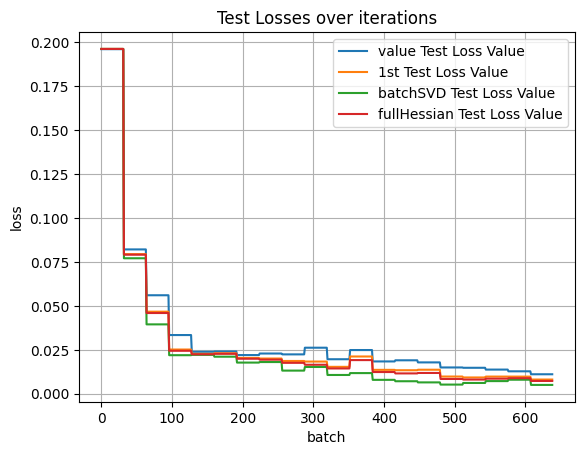

In [ ]:
#test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
#test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
#test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
#test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
#train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])

#epoch_cap = 32*50
epoch_cap = -1

for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    #test_losses_value_std = results["test_losses_values"][1]

    x = range(len(test_losses_value_mean))

    #plt.plot(x, train_losses, label='Train Loss', alpha=0.2)#, linestyle='-', marker='o')
    # Plot each of the three series
    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")#, linestyle='-', marker='o')
    #plt.plot(x, test_losses_grad, label='Test Loss Grad')#, linestyle='--', marker='s')
    #plt.plot(x, test_losses_hess, label='Test Loss Hess')#, linestyle=':', marker='^')
    #plt.plot(x, test_losses_proj_hess, label='Test Loss Proj Hess')#, linestyle=':', marker='^')


# Add labels & title
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('Test Losses over iterations')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


time per batch for value: 	0.00241s
time per batch for 1st: 	0.00260s
time per batch for batchSVD: 	0.00423s
time per batch for fullHessian: 	0.00554s


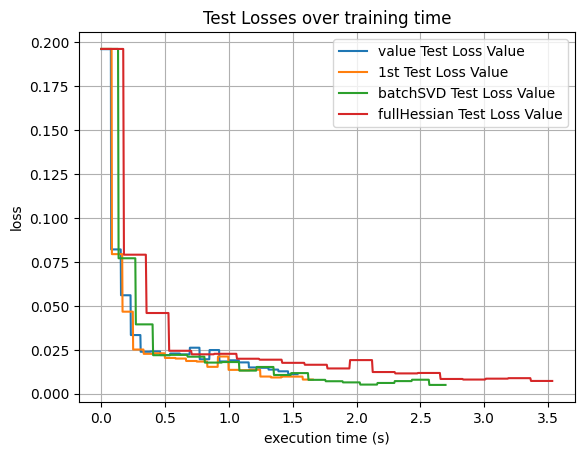

In [ ]:
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    time_per_batch = results["avg_time_per_batch"]
    print(f"time per batch for {variant}: \t{time_per_batch:.5f}s")
    #x = range(len(test_losses_value_mean))


    # TODO scale x axis by time per batch
    # Scale x-axis by execution time
    x = [i * time_per_batch for i in range(len(test_losses_value_mean))]


    

    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")
    


# Add labels & title
plt.xlabel('execution time (s)')
plt.ylabel('loss')
plt.title('Test Losses over training time')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


### all variants

In [12]:
main_key = jrandom.PRNGKey(42)


n_runs = 10

n_epochs = 200  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#4#32#8#32 # 32
BATCH_SIZE = 256#8#256#16 #256 # 256

lr = 1e-3


k = 3
streaming_r = 5



data = {}
#for variant in ["fullHessian"]:
for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    y_errors = []
    dy_errors = []
    ddy_errors = []
    eFs = []
    e2s = []
    evrs = []
    engs = []
    avg_t_p_bs = []

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        #ref_model, test_set = make_bachelier(key)
        #ref_model, test_set = make_heston(key)
        ref_model, test_set = make_analytic(key)
        #ref_model, test_set = make_MNIST(key)
        

        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        fn=ref_model.reference_fn(), 
                        ref_model=ref_model,
                        d=ref_model.n_dims, 
                        r=streaming_r,
                        k=k, 
                        key=subkey)

        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                learnable_loss_weights=True
                                )
        
    
        
        # eval price predictions
        test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set[0])
        test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set[0])
    
        test_pred_ddys = test_pred_ddys.reshape(test_set[3].shape)
        
        y_error = jnp.sqrt(mse(test_pred_ys, test_set[1]))
        dy_error = jnp.sqrt(mse(test_pred_dys, test_set[2]))
        ddy_error = jnp.sqrt(mse(test_pred_ddys, test_set[3]))
    
        y_errors.append(y_error)
        dy_errors.append(dy_error)
        ddy_errors.append(ddy_error)
        print(f"test y error: {y_error:.5f}")
        print(f"test dy error: {dy_error:.5f}")
        print(f"test ddy error: {ddy_error:.5f}")
    
        #print(iteration_datas[0])
        if "approximation metrics ref" in iteration_datas[0]:
            epochs = list(range(len(iteration_datas)))
            eF_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["eF mean"]  for t in epochs])
            e2_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["e2 mean"]  for t in epochs])
            evr_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["evr mean"] for t in epochs])
            eng_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["eng mean"] for t in epochs])
            mean_eF  = jnp.nanmean(eF_vals)
            mean_e2  = jnp.nanmean(e2_vals)
            mean_evr = jnp.nanmean(evr_vals)
            mean_eng = jnp.nanmean(eng_vals)
        else:
            mean_eF  = 0.0
            mean_e2  = 0.0
            mean_evr = 0.0
            mean_eng = 0.0
        eFs.append(mean_eF)
        e2s.append(mean_e2)
        evrs.append(mean_evr)
        engs.append(mean_eng)
        print(f"eF: {mean_eF:.5f}")
        print(f"e2: {mean_e2:.5f}")
        print(f"evr: {mean_evr:.5f}")
        print(f"eng: {mean_eng:.5f}")
        avg_t_p_bs.append(avg_time_per_batch)
        print(f"avg time per batch: {avg_time_per_batch:.5f}")

    # average the runs
    print("")
    y_errors = jnp.array(y_errors)
    dy_errors = jnp.array(dy_errors)
    ddy_errors = jnp.array(ddy_errors)

    y_errors_mean = y_errors.mean()
    dy_errors_mean = dy_errors.mean()
    ddy_errors_mean = ddy_errors.mean()
    y_errors_std = y_errors.std()
    dy_errors_std = dy_errors.std()
    ddy_errors_std = ddy_errors.std()

    print(f"y errors: \tmean: {y_errors_mean:.5f} \tstd: {y_errors_std:.5f}")
    print(f"dy errors: \tmean: {dy_errors_mean:.5f} \tstd: {dy_errors_std:.5f}")
    print(f"ddy errors: \tmean: {ddy_errors_mean:.5f} \tstd: {ddy_errors_std:.5f}")


    eFs = jnp.array(eFs)
    e2s = jnp.array(e2s)
    evrs = jnp.array(evrs)
    engs = jnp.array(engs)

    eFs_mean = eFs.mean()
    e2s_mean = e2s.mean()
    evrs_mean = evrs.mean()
    engs_mean = engs.mean()
    eFs_std = eFs.std()
    e2s_std = e2s.std()
    evrs_std = evrs.std()
    engs_std = engs.std()

    print(f"eFs: \tmean: {eFs_mean:.5f} \tstd: {eFs_std:.5f}")
    print(f"e2s: \tmean: {e2s_mean:.5f} \tstd: {e2s_std:.5f}")
    print(f"evrs: \tmean: {evrs_mean:.5f} \tstd: {evrs_std:.5f}")
    print(f"engs: \tmean: {engs_mean:.5f} \tstd: {engs_std:.5f}")



        


    data[variant] = {
        "y errors":   (y_errors_mean, y_errors_std),
        "dy errors":  (dy_errors_mean, dy_errors_std),
        "ddy errors": (ddy_errors_mean, ddy_errors_std),
        "eFs":  (eFs_mean, eFs_std),
        "e2s":  (e2s_mean, e2s_std),
        "evrs": (evrs_mean, evrs_std),
        "engs": (engs_mean, engs_std),
        "avg time per batch": jnp.array(avg_t_p_bs).mean(),
    }

    



running variant value

run 1 / 10 for value
Training for 200 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.61957 | Test Value Loss: 1.04305
Finished epoch 2 | Train Loss: 0.40712 | Test Value Loss: 0.96444
Finished epoch 3 | Train Loss: 0.36366 | Test Value Loss: 0.90692
Finished epoch 4 | Train Loss: 0.34584 | Test Value Loss: 0.84772
Finished epoch 5 | Train Loss: 0.30754 | Test Value Loss: 0.78503
Finished epoch 6 | Train Loss: 0.22322 | Test Value Loss: 0.72142
Finished epoch 7 | Train Loss: 0.18242 | Test Value Loss: 0.66351
Finished epoch 8 | Train Loss: 0.10800 | Test Value Loss: 0.61466
Finished epoch 9 | Train Loss: 0.10118 | Test Value Loss: 0.58226
Finished epoch 10 | Train Loss: 0.01579 | Test Value Loss: 0.54915
Finished epoch 11 | Train Loss: 0.00405 | Test Value Loss: 0.52492
Finished epoch 12 | Train Loss: -0.01087 | Test Value Loss: 0.51266
Finished epoch 13 | Train Loss: -0.02892 | Test Value Loss: 0.50618
Finished epoch 14 | Tr

### formatting

In [13]:
key_map = {
    "y errors": "y_error",
    "dy errors": "dy_error",
    "ddy errors": "ddy_error",
    "eFs": "eFs",
    "e2s": "e2s",
    "evrs": "evrs",
    "engs": "engs",    
    "avg time per batch": "time_p_b"
}

variant_nicknames = {
    "fullHessian": "fullHessian",
    "streaming": "streaming",
    "perXSVD": "perxRandSVD",
    "batchSVD": "batchRandSVD",
    "random": "random",
    "1st": "1st",
    "value": "value",
}

# variants that should only get y/dy/ddy errors
restricted_keys_variants = {"fullHessian", "1st", "value"}

def format_results(data, name):
    lines = []
    all_prefixes = []

    # Collect all var_prefix strings first
    for variant, results in reversed(list(data.items())):
        for k in results.keys():
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors"):
                continue
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix = f"{name}_{variant}_{suffix}"
            all_prefixes.append(var_prefix)

    # Find the maximum length for alignment
    max_len = max(len(p) for p in all_prefixes)
    max_len += 6 # account for '_mean'

    # Build the output with alignment
    for variant, results in reversed(list(data.items())):
        
        label = f"# {variant}"
        lines.append(label)
        variant_nickname = variant_nicknames.get(variant)

        for k, v in results.items():
            #(mean, std) = v
            if type(v) == tuple:
                mean, std = v 
            else:
                mean = v
                std = .0
            
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors", "avg time per batch"):
                continue
            if k in ("eFs", "e2s", "evrs", "engs"):
                offset = 0
            else:
                offset = 4
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix_mean = f"{name}_{variant_nickname}_{suffix}_mean"
            var_prefix_std = f"{name}_{variant_nickname}_{suffix}_std"
            
            # Pad with spaces so all "=" align
            lines.append(
                f"{var_prefix_mean.ljust(max_len)}, {var_prefix_std.ljust(max_len)} {''.ljust(offset)} = {mean:.5f}, {std:.5f}"
            )

        #lines.append("")  # blank line after each block

    return "\n".join(lines)
print(format_results(data, name="analyticRosenbrock"))

# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.11356, 0.00862
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.12313, 0.00982
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.12094, 0.00698
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00387, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.11224, 0.00952
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.12043, 0.01153
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.11764, 0.00902
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.68034, 0.01338
analyticRosenbrock_streami

### 0 template

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean  , bachelier_fullHessian_y_error_std         = 0., 0.
bachelier_fullHessian_dy_error_mean , bachelier_fullHessian_dy_error_std        = 0., 0.
bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std       = 0., 0.
# streaming
bachelier_streaming_y_error_mean    , bachelier_streaming_y_error_std           = 0., 0.
bachelier_streaming_dy_error_mean   , bachelier_streaming_dy_error_std          = 0., 0.
bachelier_streaming_ddy_error_mean  , bachelier_streaming_ddy_error_std         = 0., 0.
bachelier_streaming_eFs_mean        , bachelier_streaming_eFs_std           = 0., 0.
bachelier_streaming_e2s_mean        , bachelier_streaming_e2s_std           = 0., 0.
bachelier_streaming_evrs_mean       , bachelier_streaming_evrs_std          = 0., 0.
bachelier_streaming_engs_mean       , bachelier_streaming_engs_std          = 0., 0.
# perXSVD
bachelier_perxRandSVD_y_error_mean  , bachelier_perxRandSVD_y_error_std         = 0., 0.
bachelier_perxRandSVD_dy_error_mean , bachelier_perxRandSVD_dy_error_std        = 0., 0.
bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std       = 0., 0.
bachelier_perxRandSVD_eFs_mean      , bachelier_perxRandSVD_eFs_std         = 0., 0.
bachelier_perxRandSVD_e2s_mean      , bachelier_perxRandSVD_e2s_std         = 0., 0.
bachelier_perxRandSVD_evrs_mean     , bachelier_perxRandSVD_evrs_std        = 0., 0.
bachelier_perxRandSVD_engs_mean     , bachelier_perxRandSVD_engs_std        = 0., 0.
# batchSVD
bachelier_batchRandSVD_y_error_mean , bachelier_batchRandSVD_y_error_std        = 0., 0.
bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std       = 0., 0.
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std     = 0., 0.
bachelier_batchRandSVD_eFs_mean     , bachelier_batchRandSVD_eFs_std        = 0., 0.
bachelier_batchRandSVD_e2s_mean     , bachelier_batchRandSVD_e2s_std        = 0., 0.
bachelier_batchRandSVD_evrs_mean    , bachelier_batchRandSVD_evrs_std       = 0., 0.
bachelier_batchRandSVD_engs_mean    , bachelier_batchRandSVD_engs_std       = 0., 0.
# random
bachelier_random_y_error_mean       , bachelier_random_y_error_std              = 0., 0.
bachelier_random_dy_error_mean      , bachelier_random_dy_error_std             = 0., 0.
bachelier_random_ddy_error_mean     , bachelier_random_ddy_error_std            = 0., 0.
bachelier_random_eFs_mean           , bachelier_random_eFs_std              = 0., 0.
bachelier_random_e2s_mean           , bachelier_random_e2s_std              = 0., 0.
bachelier_random_evrs_mean          , bachelier_random_evrs_std             = 0., 0.
bachelier_random_engs_mean          , bachelier_random_engs_std             = 0., 0.
# 1st
bachelier_1st_y_error_mean          , bachelier_1st_y_error_std                 = 0., 0.
bachelier_1st_dy_error_mean         , bachelier_1st_dy_error_std                = 0., 0.
bachelier_1st_ddy_error_mean        , bachelier_1st_ddy_error_std               = 0., 0.
# value
bachelier_value_y_error_mean        , bachelier_value_y_error_std               = 0., 0.
bachelier_value_dy_error_mean       , bachelier_value_dy_error_std              = 0., 0.
bachelier_value_ddy_error_mean      , bachelier_value_ddy_error_std             = 0., 0.


# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0., 0.
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0., 0.
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0., 0.
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0., 0.
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0., 0.
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0., 0.
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0., 0.
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0., 0.
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0., 0.
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0., 0.
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0., 0.
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0., 0.
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0., 0.
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0., 0.
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0., 0.
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0., 0.
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0., 0.
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0., 0.
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0., 0.
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0., 0.
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0., 0.
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0., 0.
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0., 0.
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0., 0.
heston1_random_eFs_mean, heston1_random_eFs_std    = 0., 0.
heston1_random_e2s_mean, heston1_random_e2s_std    = 0., 0.
heston1_random_evrs_mean, heston1_random_evrs_std  = 0., 0.
heston1_random_engs_mean, heston1_random_engs_std  = 0., 0.
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0., 0.
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0., 0.
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0., 0.
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0., 0.
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0., 0.
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0., 0.


# TODO another run with k=2
# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0., 0.
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0., 0.
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0., 0.
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0., 0.
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0., 0.
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0., 0.
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0., 0.
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0., 0.
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0., 0.
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0., 0.
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0., 0.
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0., 0.
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0., 0.
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0., 0.
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0., 0.
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0., 0.
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0., 0.
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0., 0.
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0., 0.
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0., 0.
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0., 0.
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0., 0.
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0., 0.
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0., 0.
heston2_random_eFs_mean, heston2_random_eFs_std    = 0., 0.
heston2_random_e2s_mean, heston2_random_e2s_std    = 0., 0.
heston2_random_evrs_mean, heston2_random_evrs_std  = 0., 0.
heston2_random_engs_mean, heston2_random_engs_std  = 0., 0.
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0., 0.
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0., 0.
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0., 0.
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0., 0.
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0., 0.
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0., 0.



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0., 0.
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0., 0.
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0., 0.
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0., 0.
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0., 0.
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0., 0.
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0., 0.
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0., 0.
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0., 0.
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0., 0.
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0., 0.
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0., 0.
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0., 0.
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0., 0.
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0., 0.
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0., 0.
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0., 0.
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0., 0.
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0., 0.
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0., 0.
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0., 0.
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0., 0.
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0., 0.
heston22_random_eFs_mean, heston22_random_eFs_std    = 0., 0.
heston22_random_e2s_mean, heston22_random_e2s_std    = 0., 0.
heston22_random_evrs_mean, heston22_random_evrs_std  = 0., 0.
heston22_random_engs_mean, heston22_random_engs_std  = 0., 0.
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0., 0.
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0., 0.
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0., 0.
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0., 0.
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0., 0.
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0., 0.



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.





# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0., 0.
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0., 0.
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0., 0.
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0., 0.
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0., 0.
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0., 0.
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0., 0.
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0., 0.
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0., 0.
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0., 0.
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0., 0.
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0., 0.
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0., 0.
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0., 0.
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0., 0.
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0., 0.
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0., 0.
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0., 0.
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0., 0.
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0., 0.
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0., 0.
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0., 0.
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0., 0.
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0., 0.
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0., 0.
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0., 0.
heston7i_random_engs_mean, heston7i_random_engs_std  = 0., 0.
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0., 0.
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0., 0.
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0., 0.
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0., 0.
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0., 0.
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0., 0.





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0., 0.
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0., 0.
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0., 0.
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0., 0.
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0., 0.
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0., 0.
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0., 0.
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0., 0.
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0., 0.
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0., 0.
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0., 0.
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0., 0.
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0., 0.
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0., 0.
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0., 0.
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0., 0.
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0., 0.
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0., 0.
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0., 0.
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0., 0.




### 1st results

In [ ]:
# Bachelier basket dim 7
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00348, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 1.48164, 0.01228
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = jnp.nan, jnp.nan
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = jnp.nan, jnp.nan
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean, eFs_std =   jnp.nan, jnp.nan
bachelier_streaming_e2s_mean, e2s_std =   jnp.nan, jnp.nan
bachelier_streaming_evrs_mean, evrs_std = jnp.nan, jnp.nan
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00272, 0.00141
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 1.48152, 0.01215
bachelier_perxRandSVD_eFs_mean, eFs_std = 0.00007, 0.00002
bachelier_perxRandSVD_eFs_mean, eFs_std = 0.00000, 0.00000
bachelier_perxRandSVD_eFs_mean, eFs_std = 1.00000, 0.00000
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00270, 0.00138
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00147, 0.00035
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 1.48154, 0.01215
bachelier_batchRandSVD_eFs_mean, eFs_std = 0.00014, 0.00006
bachelier_batchRandSVD_eFs_mean, eFs_std = 0.00000, 0.00000
bachelier_batchRandSVD_eFs_mean, eFs_std = 1.00000, 0.00000
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00401, 0.00151
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00082
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 1.48246, 0.01236
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 1.48471, 0.01221


# Heston basket dim 1
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00119, 0.00015
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00335, 0.00052
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.01289, 0.00162
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = jnp.nan, jnp.nan
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = jnp.nan, jnp.nan
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = jnp.nan, jnp.nan
heston1_streaming_eFs_mean, eFs_std     = jnp.nan, jnp.nan
heston1_streaming_e2s_mean, e2s_std     = jnp.nan, jnp.nan
heston1_streaming_evrs_mean, evrs_std   = jnp.nan, jnp.nan
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.12736, 0.00671
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.17628, 0.01013
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.13891, 0.00724
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00163, 0.00046
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00456, 0.00120
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.01679, 0.00382
heston1_batchRandSVD_eFs_mean, eFs_std = 0.03666, 0.00093
heston1_batchRandSVD_eFs_mean, eFs_std = 0.03693, 0.00093
heston1_batchRandSVD_eFs_mean, eFs_std = 0.99053, 0.00067
# 2nd order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00314, 0.00072
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.01061, 0.00234
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.03245, 0.00719
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00712, 0.00085
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02548, 0.00216
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.06640, 0.00556


# Heston basket dim 2
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.10999, 0.02529
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.17072, 0.04539
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.22854, 0.03608
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = jnp.nan, jnp.nan
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = jnp.nan, jnp.nan
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = jnp.nan, jnp.nan
heston2_streaming_eFs_mean, eFs_std     = jnp.nan, jnp.nan
heston2_streaming_e2s_mean, e2s_std     = jnp.nan, jnp.nan
heston2_streaming_evrs_mean, evrs_std   = jnp.nan, jnp.nan

# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.14575, 0.01984
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.15630, 0.02036
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.50978, 0.14320
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.01516, 0.00164
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.02477, 0.00147
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.53714, 0.14063
heston2_batchRandSVD_eFs_mean, eFs_std = 0.01747, 0.00949
heston2_batchRandSVD_eFs_mean, eFs_std = 0.01749, 0.00949
heston2_batchRandSVD_eFs_mean, eFs_std = 0.99534, 0.00336
# 2nd order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00903, 0.00108
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01748, 0.00195
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.54086, 0.14087
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.01230, 0.00128
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02424, 0.00207
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.53884, 0.14154


# MNIST
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0.18107, 0.02290
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.06878, 0.00664
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.07007, 0.02046
mnist_streaming_eFs_mean, eFs_std = 0.79500, 0.03392
mnist_streaming_e2s_mean, e2s_std = 0.75567, 0.03817
mnist_streaming_evrs_mean, evrs_std = 0.35374, 0.05000
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0.17684, 0.02047
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.07267, 0.00823
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.06441, 0.01877
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0.17728, 0.02052
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.07152, 0.00819
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.06435, 0.01877
mnist_perxRandSVD_eFs_mean, eFs_std = 0.11194, 0.00337
mnist_perxRandSVD_eFs_mean, eFs_std = 0.06416, 0.01028
mnist_perxRandSVD_eFs_mean, eFs_std = 0.99469, 0.01180
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0.17737, 0.02054
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.07138, 0.00823
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.06435, 0.01878
mnist_batchRandSVD_eFs_mean, eFs_std = 0., 0.
mnist_batchRandSVD_eFs_mean, eFs_std = 0.78527, 0.01036
mnist_batchRandSVD_eFs_mean, eFs_std = 0., 0.
# 2nd order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0.17684, 0.02047
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.07265, 0.00822
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.06443, 0.01880
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0.13059, 0.01979
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.11465, 0.01498
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.07448, 0.01791



# Analytic RHE
# streaming sketch r=5, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.20802, 0.00601
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.15519, 0.00450
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.06780, 0.00193
analyticRHE_streaming_eFs_mean, eFs_std = 0.67559, 0.01955
analyticRHE_streaming_e2s_mean, e2s_std = 0.79362, 0.04693
analyticRHE_streaming_evrs_mean, evrs_std = 0.54320, 0.02649
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.05591, 0.00367
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.04254, 0.00251
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.02825, 0.00178
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.17085, 0.00557
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.14192, 0.00269
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.06776, 0.00234
analyticRHE_perxRandSVD_eFs_mean, eFs_std = 0.74060, 0.00004
analyticRHE_perxRandSVD_e2s_mean, e2s_std = 0.87299, 0.00005
analyticRHE_perxRandSVD_evrs_mean, evrs_std = 0.45041, 0.00006
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.05508, 0.00366
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.04158, 0.00247
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.02738, 0.00171
analyticRHE_batchRandSVD_eFs_mean, eFs_std = 0.74076, 0.00045
analyticRHE_batchRandSVD_e2s_mean, e2s_std = 0.87340, 0.00110
analyticRHE_batchRandSVD_evrs_mean, evrs_std = 0.45015, 0.00065
# 2nd order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.05957, 0.00395
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.04595, 0.00271
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.03101, 0.00206
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05957, 0.00395
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04595, 0.00271
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.03101, 0.00206



### 2nd 1/3 results

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00349, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 0.00340, 0.00074
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = 0.00270, 0.00143
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = 0.00147, 0.00036
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = 0.00145, 0.00030
bachelier_streaming_eFs_mean, bachelier_streaming_eFs_std   = 0.00023, 0.00005
bachelier_streaming_e2s_mean, bachelier_streaming_e2s_std   = 0.00023, 0.00005
bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std = 1.00000, 0.00000
bachelier_streaming_engs_mean, bachelier_streaming_engs_std = 0.99713, 0.00014
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00272, 0.00140
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00149, 0.00035
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_perxRandSVD_eFs_mean, bachelier_perxRandSVD_eFs_std     = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean, bachelier_perxRandSVD_e2s_std     = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std   = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean, bachelier_perxRandSVD_engs_std   = 0.99707, 0.00024
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00269, 0.00146
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00148, 0.00037
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_batchRandSVD_eFs_mean, bachelier_batchRandSVD_eFs_std    = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean, bachelier_batchRandSVD_e2s_std    = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std  = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean, bachelier_batchRandSVD_engs_std  = 0.99858, 0.00006
# random directions k=1
bachelier_random_y_error_mean,     bachelier_random_y_error_std   = 0.00350, 0.00172
bachelier_random_dy_error_mean,    bachelier_random_dy_error_std  = 0.00240, 0.00061
bachelier_random_ddy_error_mean,   bachelier_random_ddy_error_std = 0.00340, 0.00074
bachelier_random_eFs_mean, bachelier_random_eFs_std      = 0.91988, 0.00176
bachelier_random_e2s_mean, bachelier_random_e2s_std      = 0.91988, 0.00176
bachelier_random_evrs_mean, bachelier_random_evrs_std    = 0.14363, 0.00283
bachelier_random_engs_mean, bachelier_random_engs_std    = 0.14343, 0.00283
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00399, 0.00146
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00082
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 0.00541, 0.00096
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 0.00831, 0.00088



# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00085, 0.00017
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00200, 0.00037
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.00815, 0.00133
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0.00106, 0.00027
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0.00282, 0.00078
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0.01180, 0.00350
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0.83305, 0.00013
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0.83336, 0.00013
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0.24716, 0.00015
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0.24466, 0.00016
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.00093, 0.00026
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.00178, 0.00037
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.00633, 0.00101
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0.99896, 0.00002
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0.99928, 0.00001
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0.00192, 0.00003
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0.00190, 0.00003
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00126, 0.00040
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00293, 0.00069
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.00991, 0.00190
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0.99898, 0.00002
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0.99929, 0.00001
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0.00189, 0.00003
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0.00189, 0.00003
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0.00104, 0.00026
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0.00165, 0.00034
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0.00625, 0.00097
heston1_random_eFs_mean, heston1_random_eFs_std    = 0.99898, 0.00002
heston1_random_e2s_mean, heston1_random_e2s_std    = 0.99929, 0.00001
heston1_random_evrs_mean, heston1_random_evrs_std  = 0.00189, 0.00003
heston1_random_engs_mean, heston1_random_engs_std  = 0.00189, 0.00003
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00165, 0.00041
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.00572, 0.00120
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.02052, 0.00354
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00563, 0.00080
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02094, 0.00243
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.05673, 0.00617



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.10846, 0.02492
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.16920, 0.04384
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.22968, 0.03769
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0.01296, 0.00135
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0.02110, 0.00123
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0.54266, 0.14017
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0., 0.
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0., 0.
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0., 0.
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.19163, 0.03578
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.25231, 0.05482
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.15052, 0.02067
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0., 0.
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0., 0.
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0., 0.
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.18509, 0.03311
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.24430, 0.05210
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.15722, 0.02331
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0., 0.
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0., 0.
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0., 0.
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0., 0.
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0.15331, 0.02874
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0.21331, 0.04749
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0.18312, 0.03120
heston2_random_eFs_mean, heston2_random_eFs_std    = 0., 0.
heston2_random_e2s_mean, heston2_random_e2s_std    = 0., 0.
heston2_random_evrs_mean, heston2_random_evrs_std  = 0., 0.
heston2_random_engs_mean, heston2_random_engs_std  = 0., 0.
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00586, 0.00096
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01192, 0.00182
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.54432, 0.13979
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.00971, 0.00120
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02081, 0.00211
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.53971, 0.14115



# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 1.12795, 0.08516
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.56311, 0.02843
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.13290, 0.00997
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 1.12568, 0.08543
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.56311, 0.02847
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.13250, 0.00990
mnist_streaming_eFs_mean, mnist_streaming_eFs_std =   0.79909, 0.02194
mnist_streaming_e2s_mean, mnist_streaming_e2s_std =   0.77617, 0.03045
mnist_streaming_evrs_mean, mnist_streaming_evrs_std = 0.35789, 0.03450
mnist_streaming_engs_mean, mnist_streaming_evrs_std = 0.28981, 0.02832
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 1.09861, 0.08632
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.55786, 0.02721
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.13024, 0.00896
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std     = 0.75002, 0.01145
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_eFs_std     = 0.71025, 0.00876
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_eFs_std    = 0.42580, 0.01629
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_eFs_std    = 0.20570, 0.01224
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 1.10332, 0.08872
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.55759, 0.02630
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.12930, 0.00888
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std    = 0.87245, 0.00800
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_eFs_std    = 0.86427, 0.00858
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_eFs_std   = 0.23708, 0.01382
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_eFs_std   = 0.23708, 0.01382
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 1.12824, 0.08493
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0.56186, 0.02807
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0.13218, 0.00983
mnist_random_eFs_mean, mnist_random_eFs_std  = 0.98717, 0.00008
mnist_random_e2s_mean, mnist_random_e2s_std  = 0.98755, 0.00012
mnist_random_evrs_mean, mnist_random_eFs_std = 0.02544, 0.00016
mnist_random_engs_mean, mnist_random_eFs_std = 0.02544, 0.00016
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 1.12795, 0.08512
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.56326, 0.02847
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.13300, 0.01000
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 1.12670, 0.08809
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.62078, 0.03780
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.13501, 0.01049



# TODO redo for k=3
# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.03841, 0.00304
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.02901, 0.00166
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.01949, 0.00131
# streaming sketch r=2, k=1
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.03761, 0.00250
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.02838, 0.00135
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.01884, 0.00107
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=1
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.03744, 0.00301
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.02808, 0.00161
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.01861, 0.00120
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.03746, 0.00287
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.02807, 0.00159
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.01861, 0.00120
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=1
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0.03826, 0.00287
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0.02900, 0.00164
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0.01950, 0.00130
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.04193, 0.00309
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.03217, 0.00179
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.02224, 0.00155
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05254, 0.00336
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04244, 0.00262
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.02976, 0.00251



### 3rd fixed scaling and normalization

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00347, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 0.00340, 0.00074
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = 0.00273, 0.00139
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = 0.00148, 0.00036
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = 0.00145, 0.00030
bachelier_streaming_eFs_mean, bachelier_streaming_eFs_std   = 0.00023, 0.00005
bachelier_streaming_e2s_mean, bachelier_streaming_e2s_std   = 0.00023, 0.00005
bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std = 1.00000, 0.00000
bachelier_streaming_engs_mean, bachelier_streaming_engs_std = 0.99713, 0.00014
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00275, 0.00142
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_perxRandSVD_eFs_mean, bachelier_perxRandSVD_eFs_std     = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean, bachelier_perxRandSVD_e2s_std     = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std   = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean, bachelier_perxRandSVD_engs_std   = 0.99707, 0.00024
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00274, 0.00144
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_batchRandSVD_eFs_mean, bachelier_batchRandSVD_eFs_std    = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean, bachelier_batchRandSVD_e2s_std    = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std  = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean, bachelier_batchRandSVD_engs_std  = 0.99858, 0.00006
# random directions k=1
bachelier_random_y_error_mean,     bachelier_random_y_error_std   = 0.00348, 0.00165
bachelier_random_dy_error_mean,    bachelier_random_dy_error_std  = 0.00240, 0.00060
bachelier_random_ddy_error_mean,   bachelier_random_ddy_error_std = 0.00340, 0.00074
bachelier_random_eFs_mean, bachelier_random_eFs_std      = 0.91988, 0.00176
bachelier_random_e2s_mean, bachelier_random_e2s_std      = 0.91988, 0.00176
bachelier_random_evrs_mean, bachelier_random_evrs_std    = 0.14363, 0.00283
bachelier_random_engs_mean, bachelier_random_engs_std    = 0.14343, 0.00283
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00403, 0.00154
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00083
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 0.00541, 0.00096
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 0.00831, 0.00088



# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00083, 0.00019
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00199, 0.00038
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.00815, 0.00133
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0.00115, 0.00042
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0.00285, 0.00080
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0.01187, 0.00354
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0.00207, 0.00003
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0.00228, 0.00004
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0.99936, 0.00002
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0.99487, 0.00005
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.00110, 0.00021
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.00285, 0.00077
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.01187, 0.00354
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0.02305, 0.00007
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0.02331, 0.00008
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0.99475, 0.00005
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0.99321, 0.00005
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00111, 0.00030
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00284, 0.00079
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.01187, 0.00353
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0.03674, 0.00094
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0.03700, 0.00093
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0.99065, 0.00075
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0.99065, 0.00075
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0.00098, 0.00025
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0.00208, 0.00037
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0.00837, 0.00132
heston1_random_eFs_mean, heston1_random_eFs_std    = 0.63373, 0.00326
heston1_random_e2s_mean, heston1_random_e2s_std    = 0.63402, 0.00326
heston1_random_evrs_mean, heston1_random_evrs_std  = 0.50341, 0.00314
heston1_random_engs_mean, heston1_random_engs_std  = 0.50341, 0.00314
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00167, 0.00041
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.00572, 0.00120
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.02052, 0.00354
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00563, 0.00080
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02094, 0.00243
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.05673, 0.00617


# TODO another run with k=2
# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.00384, 0.00054
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.00715, 0.00094
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.01331, 0.00155
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0.00461, 0.00079
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0.00872, 0.00142
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0.01667, 0.00235
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0.34837, 0.04370
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0.39882, 0.04538
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0.83305, 0.03707
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0.57370, 0.07753
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.00452, 0.00082
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.00879, 0.00152
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.01704, 0.00255
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0.59147, 0.04704
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0.65830, 0.05692
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0.58265, 0.04474
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0.55259, 0.05049
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.00472, 0.00087
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.00917, 0.00166
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.01768, 0.00286
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0.61504, 0.05765
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0.68232, 0.06803
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0.56146, 0.05814
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0.56146, 0.05814
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0.00400, 0.00052
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0.00727, 0.00099
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0.01345, 0.00159
heston2_random_eFs_mean, heston2_random_eFs_std    = 0.85349, 0.00160
heston2_random_e2s_mean, heston2_random_e2s_std    = 0.87317, 0.00349
heston2_random_evrs_mean, heston2_random_evrs_std  = 0.25188, 0.00260
heston2_random_engs_mean, heston2_random_engs_std  = 0.25188, 0.00260
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00587, 0.00095
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01193, 0.00183
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.02222, 0.00327
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.00971, 0.00120
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02081, 0.00211
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.03589, 0.00328



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0.00389, 0.00056
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0.00711, 0.00093
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0.01323, 0.00148
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0.00466, 0.00085
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0.00919, 0.00163
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0.01784, 0.00277
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0.00022, 0.00004
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0.00023, 0.00005
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0.99999, 0.00000
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0.99666, 0.00003
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0.00467, 0.00083
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0.00919, 0.00163
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0.01784, 0.00277
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0.02231, 0.00008
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0.02437, 0.00029
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0.99615, 0.00021
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0.99381, 0.00003
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0.00468, 0.00085
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0.00919, 0.00163
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0.01784, 0.00277
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0.04381, 0.00104
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0.04807, 0.00115
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0.98923, 0.00051
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0.98923, 0.00051
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0.00390, 0.00053
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0.00716, 0.00094
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0.01329, 0.00150
heston22_random_eFs_mean, heston22_random_eFs_std    = 0.67935, 0.00280
heston22_random_e2s_mean, heston22_random_e2s_std    = 0.71484, 0.00694
heston22_random_evrs_mean, heston22_random_evrs_std  = 0.50041, 0.00299
heston22_random_engs_mean, heston22_random_engs_std  = 0.50041, 0.00299
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0.00588, 0.00099
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0.01181, 0.00180
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0.02207, 0.00327
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0.00956, 0.00121
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0.02055, 0.00214
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0.03572, 0.00351



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0.02385, 0.00180
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0.01708, 0.00120
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0.01253, 0.00088
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0.02438, 0.00179
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0.01788, 0.00130
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0.01331, 0.00096
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0.61574, 0.04131
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0.65097, 0.04229
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0.60223, 0.04504
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0.37582, 0.02635
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0.02428, 0.00177
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0.01785, 0.00131
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0.01330, 0.00097
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0.70657, 0.01165
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0.74169, 0.01046
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0.47168, 0.01445
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0.36881, 0.01924
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0.02438, 0.00179
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0.01787, 0.00131
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0.01329, 0.00097
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0.77608, 0.01593
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0.81999, 0.01557
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0.38200, 0.02263
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0.38200, 0.02263
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0.02387, 0.00176
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0.01708, 0.00119
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0.01253, 0.00088
heston7_random_eFs_mean, heston7_random_eFs_std    = 0.92467, 0.00024
heston7_random_e2s_mean, heston7_random_e2s_std    = 0.93513, 0.00041
heston7_random_evrs_mean, heston7_random_evrs_std  = 0.14261, 0.00041
heston7_random_engs_mean, heston7_random_engs_std  = 0.14261, 0.00041
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0.02467, 0.00180
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0.01805, 0.00132
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0.01339, 0.00095
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0.02793, 0.00196
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0.02107, 0.00154
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0.01519, 0.00101





# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0.02387, 0.00182
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0.01707, 0.00121
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0.01252, 0.00088
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0.02432, 0.00178
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0.01789, 0.00131
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0.01333, 0.00097
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0.62094, 0.04129
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0.65681, 0.04229
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0.59609, 0.04596
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0.37288, 0.02694
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0.02424, 0.00180
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0.01787, 0.00132
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0.01332, 0.00098
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0.70679, 0.01161
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0.74194, 0.01044
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0.47136, 0.01440
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0.36847, 0.01915
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0.02436, 0.00180
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0.01788, 0.00132
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0.01331, 0.00097
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0.77886, 0.01507
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0.82226, 0.01482
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0.37817, 0.02151
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0.37817, 0.02151
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0.02382, 0.00180
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0.01707, 0.00121
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0.01252, 0.00088
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0.92467, 0.00024
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0.93513, 0.00041
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0.14261, 0.00041
heston7i_random_engs_mean, heston7i_random_engs_std  = 0.14261, 0.00041
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0.02465, 0.00183
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0.01803, 0.00133
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0.01339, 0.00096
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0.02793, 0.00192
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0.02107, 0.00155
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0.01519, 0.00101





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0.20206, 0.01794
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.10613, 0.00549
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.03202, 0.00224
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0.19927, 0.01650
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.10285, 0.00493
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.03077, 0.00184
mnist_streaming_eFs_mean, mnist_streaming_eFs_std =   0.75199, 0.03291
mnist_streaming_e2s_mean, mnist_streaming_e2s_std =   0.69683, 0.05466
mnist_streaming_evrs_mean, mnist_streaming_evrs_std = 0.43077, 0.04784
mnist_streaming_engs_mean, mnist_streaming_evrs_std = 0.37421, 0.03840
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0.19916, 0.01707
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.10310, 0.00489
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.03091, 0.00191
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std     = 0.72666, 0.02169
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std     = 0.70601, 0.03057
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std    = 0.46817, 0.03043
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std    = 0.28787, 0.02455
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0.19962, 0.01698
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.10309, 0.00485
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.03076, 0.00190
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std    = 0.80727, 0.01885
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std    = 0.79165, 0.02728
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0.34549, 0.02962
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0.34549, 0.02962
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0.20205, 0.01795
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0.10615, 0.00549
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0.03202, 0.00224
mnist_random_eFs_mean, mnist_random_eFs_std  = 0.98717, 0.00005
mnist_random_e2s_mean, mnist_random_e2s_std  = 0.98771, 0.00011
mnist_random_evrs_mean, mnist_random_evrs_std = 0.02544, 0.00009
mnist_random_engs_mean, mnist_random_engs_std = 0.02544, 0.00009
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0.20218, 0.01801
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.10660, 0.00556
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.03229, 0.00226
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0.20956, 0.02146
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.16158, 0.01360
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.04103, 0.00219


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.03844, 0.00309
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.02901, 0.00167
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.01949, 0.00131
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.03737, 0.00298
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.02805, 0.00162
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.01857, 0.00121
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0.67532, 0.01958
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0.79362, 0.04692
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0.54322, 0.02649
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0.54322, 0.02649
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.03747, 0.00299
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.02820, 0.00161
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.01873, 0.00122
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0.74039, 0.00003
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0.87298, 0.00006
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0.45041, 0.00004
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0.45041, 0.00004
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.03753, 0.00293
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.02820, 0.00161
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.01873, 0.00122
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0.74044, 0.00030
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0.87301, 0.00059
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0.45033, 0.00044
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0.45033, 0.00044
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0.03844, 0.00297
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0.02902, 0.00165
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0.01950, 0.00130
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0.83612, 0.00026
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0.92293, 0.00056
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0.29970, 0.00044
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0.29970, 0.00044
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.04187, 0.00306
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.03215, 0.00180
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.02224, 0.00155
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05255, 0.00339
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04244, 0.00262
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.02976, 0.00251


### 4th cleanup, new analytic functions

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std         = 0.00345, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std        = 0.00239, 0.00056
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std       = 0.00340, 0.00074
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std           = 0.00272, 0.00138
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std          = 0.00148, 0.00035
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std         = 0.00144, 0.00030
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std           = 0.00023, 0.00005
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std           = 0.00023, 0.00005
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std          = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std          = 0.99713, 0.00014
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std         = 0.00269, 0.00139
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std        = 0.00147, 0.00035
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std       = 0.00144, 0.00030
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std         = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std         = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std        = 0.99707, 0.00024
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std        = 0.00270, 0.00143
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std       = 0.00148, 0.00036
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std      = 0.00144, 0.00030
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std        = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std        = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std       = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std       = 0.99858, 0.00006
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std              = 0.00352, 0.00169
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std             = 0.00240, 0.00061
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std            = 0.00341, 0.00074
bachelier_random_eFs_mean            , bachelier_random_eFs_std              = 0.91988, 0.00176
bachelier_random_e2s_mean            , bachelier_random_e2s_std              = 0.91988, 0.00176
bachelier_random_evrs_mean           , bachelier_random_evrs_std             = 0.14363, 0.00283
bachelier_random_engs_mean           , bachelier_random_engs_std             = 0.14343, 0.00283
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                 = 0.00403, 0.00154
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                = 0.00367, 0.00083
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std               = 0.00542, 0.00096
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std               = 0.00465, 0.00094
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std              = 0.00592, 0.00079
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std             = 0.00832, 0.00088


# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=1, r=2
# fullHessian
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00086, 0.00021
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00198, 0.00036
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00811, 0.00124
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00105, 0.00010
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00292, 0.00040
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.01138, 0.00135
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00008
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00009
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00019
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00106, 0.00022
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00236, 0.00035
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00931, 0.00114
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20973, 0.00012
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21291, 0.00013
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90810, 0.00009
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81132, 0.00024
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00096, 0.00016
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00244, 0.00027
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.01030, 0.00082
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26199, 0.00133
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26556, 0.00134
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89248, 0.00134
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89248, 0.00134
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00095, 0.00021
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00206, 0.00036
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00833, 0.00119
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64620, 0.00196
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65134, 0.00197
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49714, 0.00273
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49714, 0.00273
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00166, 0.00040
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00570, 0.00112
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.02033, 0.00348
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00570, 0.00084
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.02082, 0.00285
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.05623, 0.00700


# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=1, r=2
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00385, 0.00054
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00710, 0.00093
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.01323, 0.00148
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00410, 0.00052
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00754, 0.00096
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.01383, 0.00157
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48263, 0.06072
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.52397, 0.08329
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73754, 0.05424
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.58937, 0.09630
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00388, 0.00048
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00710, 0.00086
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.01311, 0.00149
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58058, 0.05133
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65353, 0.07761
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61937, 0.04660
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49695, 0.05714
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00386, 0.00057
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00696, 0.00078
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.01269, 0.00122
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64514, 0.06344
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71282, 0.09378
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54599, 0.06877
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54599, 0.06877
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00392, 0.00056
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00722, 0.00097
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.01336, 0.00153
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85757, 0.00270
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88467, 0.01155
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24886, 0.00231
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24886, 0.00231
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00587, 0.00099
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.01181, 0.00181
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.02207, 0.00327
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00957, 0.00119
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.02055, 0.00214
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.03572, 0.00351



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0., 0.
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0., 0.
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0., 0.
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0., 0.
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0., 0.
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0., 0.
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0., 0.
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0., 0.
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0., 0.
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0., 0.
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0., 0.
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0., 0.
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0., 0.
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0., 0.
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0., 0.
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0., 0.
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0., 0.
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0., 0.
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0., 0.
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0., 0.
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0., 0.
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0., 0.
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0., 0.
heston22_random_eFs_mean, heston22_random_eFs_std    = 0., 0.
heston22_random_e2s_mean, heston22_random_e2s_std    = 0., 0.
heston22_random_evrs_mean, heston22_random_evrs_std  = 0., 0.
heston22_random_engs_mean, heston22_random_engs_std  = 0., 0.
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0., 0.
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0., 0.
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0., 0.
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0., 0.
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0., 0.
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0., 0.



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.






# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02978, 0.00316
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.02125, 0.00208
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01402, 0.00140
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02956, 0.00347
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.02068, 0.00214
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01347, 0.00142
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67532, 0.01958
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.79363, 0.04692
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54269, 0.02644
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54269, 0.02644
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02970, 0.00308
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.02072, 0.00212
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01353, 0.00139
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74039, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87298, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45000, 0.00015
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45000, 0.00015
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02938, 0.00308
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.02072, 0.00209
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01353, 0.00138
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74044, 0.00030
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87301, 0.00059
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44992, 0.00048
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44992, 0.00048
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02966, 0.00288
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.02125, 0.00209
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01402, 0.00140
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83612, 0.00026
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92293, 0.00056
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00040
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00040
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.03129, 0.00255
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.02354, 0.00207
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01593, 0.00148
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.04083, 0.00312
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.03207, 0.00225
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.02199, 0.00177



# Analytic Rosenbrock | epochs=400, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.08142, 0.01400
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.08246, 0.01054
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.08678, 0.00737
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.07914, 0.01078
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.07713, 0.01112
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.08011, 0.00967
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.68034, 0.01340
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.74503, 0.02044
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.52995, 0.01943
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34289, 0.01244
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.08002, 0.01219
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.07645, 0.00992
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.07854, 0.00767
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00005
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58180, 0.00007
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72324, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.07992, 0.01229
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.08066, 0.01041
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.08509, 0.00769
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80515, 0.00011
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85147, 0.00013
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34611, 0.00017
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34611, 0.00017
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.07915, 0.01203
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.08103, 0.00967
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.08605, 0.00721
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83422, 0.00012
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87428, 0.00011
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29958, 0.00020
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29958, 0.00020
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.08373, 0.01359
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.09273, 0.01242
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.10384, 0.00934
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.11390, 0.01082
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.15154, 0.01439
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.16237, 0.01291


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.25407, 0.00379
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36244, 0.01403
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.02889, 0.07955
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.25493, 0.00439
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36321, 0.01392
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.02890, 0.07954
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.79928, 0.00390
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.95451, 0.00134
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.35957, 0.00605
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29981, 0.00005
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.25909, 0.00395
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36241, 0.01401
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.02896, 0.07956
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76338, 0.00002
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00005
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41486, 0.00003
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.25172, 0.00415
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36361, 0.01403
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.02887, 0.07954
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83572, 0.00004
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96812, 0.00003
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29977, 0.00006
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29977, 0.00006
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.25507, 0.00399
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36249, 0.01399
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.02890, 0.07955
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83624, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96378, 0.00004
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29958, 0.00004
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29958, 0.00004
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.25275, 0.00405
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36186, 0.01398
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.02901, 0.07956
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24861, 0.00396
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36503, 0.01391
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.02896, 0.07951

### 5th merge, learnable loss balancing

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00382, 0.00211
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00217, 0.00068
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00237, 0.00064
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00635, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00350, 0.00206
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00175, 0.00076
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00112, 0.00029
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00023, 0.00005
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00023, 0.00005
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99713, 0.00014
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02275, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00345, 0.00210
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00176, 0.00079
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00113, 0.00031
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99707, 0.00024
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03848, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00346, 0.00207
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00175, 0.00076
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00112, 0.00030
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99858, 0.00006
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00778, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00393, 0.00217
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00219, 0.00067
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00238, 0.00062
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92048, 0.00180
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92048, 0.00180
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14280, 0.00275
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14260, 0.00274
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00685, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00440, 0.00239
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00298, 0.00082
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00397, 0.00090
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00416, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00531, 0.00269
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00386, 0.00106
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00525, 0.00092
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00306, 0.00000




# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00328, 0.00097
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00419, 0.00045
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00851, 0.00092
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.00653, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00294, 0.00047
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00485, 0.00048
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00965, 0.00094
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48263, 0.06072
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.52397, 0.08329
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73754, 0.05424
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.58937, 0.09630
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.02373, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00319, 0.00035
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00447, 0.00035
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00883, 0.00083
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58062, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65356, 0.07765
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61936, 0.04664
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49697, 0.05716
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.03754, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00325, 0.00074
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00458, 0.00065
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00902, 0.00099
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64652, 0.06294
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71433, 0.09335
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54430, 0.06815
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54430, 0.06815
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.00798, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00359, 0.00079
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00427, 0.00045
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00863, 0.00092
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85629, 0.00180
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88393, 0.01043
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.25090, 0.00223
heston2_random_engs_mean           , heston2_random_engs_std              = 0.25090, 0.00223
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.00665, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00455, 0.00100
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00838, 0.00122
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01654, 0.00223
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00411, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00618, 0.00082
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01332, 0.00194
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02508, 0.00338
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00347, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.





# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0., 0.
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0., 0.
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0., 0.
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0., 0.
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0., 0.
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0., 0.
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0., 0.
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0., 0.
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0., 0.
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0., 0.
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0., 0.
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0., 0.
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0., 0.
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0., 0.
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0., 0.
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0., 0.
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0., 0.
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0., 0.
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0., 0.
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0., 0.
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0., 0.
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0., 0.
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0., 0.
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0., 0.
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0., 0.
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0., 0.
heston7i_random_engs_mean, heston7i_random_engs_std  = 0., 0.
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0., 0.
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0., 0.
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0., 0.
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0., 0.
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0., 0.
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0., 0.





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0., 0.
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0., 0.
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0., 0.
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0., 0.
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0., 0.
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0., 0.
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0., 0.
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0., 0.
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0., 0.
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0., 0.
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0., 0.
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0., 0.
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0., 0.
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0., 0.
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0., 0.
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0., 0.
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0., 0.
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0., 0.
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0., 0.
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0., 0.




# Analytic Rosenbrock | epochs=200, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.11356, 0.00862
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.12313, 0.00982
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.12094, 0.00698
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00387, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.11224, 0.00952
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.12043, 0.01153
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.11764, 0.00902
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.68034, 0.01338
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.74503, 0.02041
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.52995, 0.01941
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34289, 0.01244
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.01969, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.11221, 0.00814
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.11918, 0.01023
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.11504, 0.00813
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50880, 0.00012
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58173, 0.00017
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72329, 0.00011
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33801, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03454, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.11426, 0.00895
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.12351, 0.00987
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.12061, 0.00693
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00012
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85078, 0.00013
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34722, 0.00018
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34722, 0.00018
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00542, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.11350, 0.00846
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.12295, 0.00972
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.12079, 0.00689
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83424, 0.00021
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87436, 0.00021
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29953, 0.00034
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29953, 0.00034
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00471, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.11914, 0.00770
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.14299, 0.00892
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.14923, 0.00785
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00284, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13382, 0.01334
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.17780, 0.01660
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.18680, 0.01494
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00159, 0.00000

# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0., 0.
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 0., 0.
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 0., 0.
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0., 0.
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 0., 0.
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 0., 0.
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0., 0.
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0., 0.
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0., 0.
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0., 0.
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0., 0.
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 0., 0.
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 0., 0.
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0., 0.
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0., 0.
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0., 0.
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0., 0.
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0., 0.
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 0., 0.
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 0., 0.
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0., 0.
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0., 0.
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0., 0.
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0., 0.
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0., 0.
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 0., 0.
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 0., 0.
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0., 0.
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0., 0.
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0., 0.
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0., 0.
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0., 0.
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 0., 0.
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 0., 0.
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0., 0.
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 0., 0.
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 0., 0.


## plots

In [16]:
# Replace numerical values in raw_data with the corresponding variable names (no quotes)
raw_data = {
    "Bachelier": {
        "y error": [
            ("fullHessian", bachelier_fullHessian_y_error_mean, bachelier_fullHessian_y_error_std),
            ("streaming", bachelier_streaming_y_error_mean, bachelier_streaming_y_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_y_error_mean, bachelier_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_y_error_mean, bachelier_batchRandSVD_y_error_std),
            ("random", bachelier_random_y_error_mean, bachelier_random_y_error_std),
            ("1st", bachelier_1st_y_error_mean, bachelier_1st_y_error_std),
            ("value", bachelier_value_y_error_mean, bachelier_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", bachelier_fullHessian_dy_error_mean, bachelier_fullHessian_dy_error_std),
            ("streaming", bachelier_streaming_dy_error_mean, bachelier_streaming_dy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_dy_error_mean, bachelier_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std),
            ("random", bachelier_random_dy_error_mean, bachelier_random_dy_error_std),
            ("1st", bachelier_1st_dy_error_mean, bachelier_1st_dy_error_std),
            ("value", bachelier_value_dy_error_mean, bachelier_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std),
            ("streaming", bachelier_streaming_ddy_error_mean, bachelier_streaming_ddy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std),
            ("random", bachelier_random_ddy_error_mean, bachelier_random_ddy_error_std),
            ("1st", bachelier_1st_ddy_error_mean, bachelier_1st_ddy_error_std),
            ("value", bachelier_value_ddy_error_mean, bachelier_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std),
            ("perxRandSVD", bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std),
            ("random", bachelier_random_evrs_mean, bachelier_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    #"Heston1": {
    #    "y error": [
    #        ("fullHessian", heston1_fullHessian_y_error_mean, heston1_fullHessian_y_error_std),
    #        ("streaming", heston1_streaming_y_error_mean, heston1_streaming_y_error_std),
    #        ("perxRandSVD", heston1_perxRandSVD_y_error_mean, heston1_perxRandSVD_y_error_std),
    #        ("batchRandSVD", heston1_batchRandSVD_y_error_mean, heston1_batchRandSVD_y_error_std),
    #        ("random", heston1_random_y_error_mean, heston1_random_y_error_std),
    #        ("1st", heston1_1st_y_error_mean, heston1_1st_y_error_std),
    #        ("value", heston1_value_y_error_mean, heston1_value_y_error_std),
    #    ],
    #    "dydx error": [
    #        ("fullHessian", heston1_fullHessian_dy_error_mean, heston1_fullHessian_dy_error_std),
    #        ("streaming", heston1_streaming_dy_error_mean, heston1_streaming_dy_error_std),
    #        ("perxRandSVD", heston1_perxRandSVD_dy_error_mean, heston1_perxRandSVD_dy_error_std),
    #        ("batchRandSVD", heston1_batchRandSVD_dy_error_mean, heston1_batchRandSVD_dy_error_std),
    #        ("random", heston1_random_dy_error_mean, heston1_random_dy_error_std),
    #        ("1st", heston1_1st_dy_error_mean, heston1_1st_dy_error_std),
    #        ("value", heston1_value_dy_error_mean, heston1_value_dy_error_std),
    #    ],
    #    "ddyddx error": [
    #        ("fullHessian", heston1_fullHessian_ddy_error_mean, heston1_fullHessian_ddy_error_std),
    #        ("streaming", heston1_streaming_ddy_error_mean, heston1_streaming_ddy_error_std),
    #        ("perxRandSVD", heston1_perxRandSVD_ddy_error_mean, heston1_perxRandSVD_ddy_error_std),
    #        ("batchRandSVD", heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std),
    #        ("random", heston1_random_ddy_error_mean, heston1_random_ddy_error_std),
    #        ("1st", heston1_1st_ddy_error_mean, heston1_1st_ddy_error_std),
    #        ("value", heston1_value_ddy_error_mean, heston1_value_ddy_error_std),
    #    ],
    #    "evr": [
    #        ("fullHessian", 1.0, 0.0),
    #        ("streaming", heston1_streaming_evrs_mean, heston1_streaming_evrs_std),
    #        ("perxRandSVD", heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std),
    #        ("batchRandSVD", heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std),
    #        ("random", heston1_random_evrs_mean, heston1_random_evrs_std),
    #        ("1st", jnp.nan, jnp.nan),
    #        ("value", jnp.nan, jnp.nan),
    #    ]
    #},
    "Heston2": {
        "y error": [
            ("fullHessian", heston2_fullHessian_y_error_mean, heston2_fullHessian_y_error_std),
            ("streaming", heston2_streaming_y_error_mean, heston2_streaming_y_error_std),
            ("perxRandSVD", heston2_perxRandSVD_y_error_mean, heston2_perxRandSVD_y_error_std),
            ("batchRandSVD", heston2_batchRandSVD_y_error_mean, heston2_batchRandSVD_y_error_std),
            ("random", heston2_random_y_error_mean, heston2_random_y_error_std),
            ("1st", heston2_1st_y_error_mean, heston2_1st_y_error_std),
            ("value", heston2_value_y_error_mean, heston2_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", heston2_fullHessian_dy_error_mean, heston2_fullHessian_dy_error_std),
            ("streaming", heston2_streaming_dy_error_mean, heston2_streaming_dy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_dy_error_mean, heston2_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_dy_error_mean, heston2_batchRandSVD_dy_error_std),
            ("random", heston2_random_dy_error_mean, heston2_random_dy_error_std),
            ("1st", heston2_1st_dy_error_mean, heston2_1st_dy_error_std),
            ("value", heston2_value_dy_error_mean, heston2_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", heston2_fullHessian_ddy_error_mean, heston2_fullHessian_ddy_error_std),
            ("streaming", heston2_streaming_ddy_error_mean, heston2_streaming_ddy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_ddy_error_mean, heston2_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std),
            ("random", heston2_random_ddy_error_mean, heston2_random_ddy_error_std),
            ("1st", heston2_1st_ddy_error_mean, heston2_1st_ddy_error_std),
            ("value", heston2_value_ddy_error_mean, heston2_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston2_streaming_evrs_mean, heston2_streaming_evrs_std),
            ("perxRandSVD", heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std),
            ("batchRandSVD", heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std),
            ("random", heston2_random_evrs_mean, heston2_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston7": {
        "y error": [
            ("fullHessian", heston7_fullHessian_y_error_mean, heston7_fullHessian_y_error_std),
            ("streaming", heston7_streaming_y_error_mean, heston7_streaming_y_error_std),
            ("perxRandSVD", heston7_perxRandSVD_y_error_mean, heston7_perxRandSVD_y_error_std),
            ("batchRandSVD", heston7_batchRandSVD_y_error_mean, heston7_batchRandSVD_y_error_std),
            ("random", heston7_random_y_error_mean, heston7_random_y_error_std),
            ("1st", heston7_1st_y_error_mean, heston7_1st_y_error_std),
            ("value", heston7_value_y_error_mean, heston7_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", heston7_fullHessian_dy_error_mean, heston7_fullHessian_dy_error_std),
            ("streaming", heston7_streaming_dy_error_mean, heston7_streaming_dy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_dy_error_mean, heston7_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_dy_error_mean, heston7_batchRandSVD_dy_error_std),
            ("random", heston7_random_dy_error_mean, heston7_random_dy_error_std),
            ("1st", heston7_1st_dy_error_mean, heston7_1st_dy_error_std),
            ("value", heston7_value_dy_error_mean, heston7_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", heston7_fullHessian_ddy_error_mean, heston7_fullHessian_ddy_error_std),
            ("streaming", heston7_streaming_ddy_error_mean, heston7_streaming_ddy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_ddy_error_mean, heston7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std),
            ("random", heston7_random_ddy_error_mean, heston7_random_ddy_error_std),
            ("1st", heston7_1st_ddy_error_mean, heston7_1st_ddy_error_std),
            ("value", heston7_value_ddy_error_mean, heston7_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston7_streaming_evrs_mean, heston7_streaming_evrs_std),
            ("perxRandSVD", heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std),
            ("batchRandSVD", heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std),
            ("random", heston7_random_evrs_mean, heston7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "MNIST": {
        "y error": [
            ("fullHessian", mnist_fullHessian_y_error_mean, mnist_fullHessian_y_error_std),
            ("streaming", mnist_streaming_y_error_mean, mnist_streaming_y_error_std),
            ("perxRandSVD", mnist_perxRandSVD_y_error_mean, mnist_perxRandSVD_y_error_std),
            ("batchRandSVD", mnist_batchRandSVD_y_error_mean, mnist_batchRandSVD_y_error_std),
            ("random", mnist_random_y_error_mean, mnist_random_y_error_std),
            ("1st", mnist_1st_y_error_mean, mnist_1st_y_error_std),
            ("value", mnist_value_y_error_mean, mnist_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", mnist_fullHessian_dy_error_mean, mnist_fullHessian_dy_error_std),
            ("streaming", mnist_streaming_dy_error_mean, mnist_streaming_dy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_dy_error_mean, mnist_perxRandSVD_dy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std),
            ("random", mnist_random_dy_error_mean, mnist_random_dy_error_std),
            ("1st", mnist_1st_dy_error_mean, mnist_1st_dy_error_std),
            ("value", mnist_value_dy_error_mean, mnist_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", mnist_fullHessian_ddy_error_mean, mnist_fullHessian_ddy_error_std),
            ("streaming", mnist_streaming_ddy_error_mean, mnist_streaming_ddy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std),
            ("random", mnist_random_ddy_error_mean, mnist_random_ddy_error_std),
            ("1st", mnist_1st_ddy_error_mean, mnist_1st_ddy_error_std),
            ("value", mnist_value_ddy_error_mean, mnist_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", mnist_streaming_evrs_mean, mnist_streaming_evrs_std),
            ("perxRandSVD", mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std),
            ("batchRandSVD", mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std),
            ("random", mnist_random_evrs_mean, mnist_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRHE": {
        "y error": [
            ("fullHessian", analyticRHE_fullHessian_y_error_mean, analyticRHE_fullHessian_y_error_std),
            ("streaming", analyticRHE_streaming_y_error_mean, analyticRHE_streaming_y_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_y_error_mean, analyticRHE_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_y_error_mean, analyticRHE_batchRandSVD_y_error_std),
            ("random", analyticRHE_random_y_error_mean, analyticRHE_random_y_error_std),
            ("1st", analyticRHE_1st_y_error_mean, analyticRHE_1st_y_error_std),
            ("value", analyticRHE_value_y_error_mean, analyticRHE_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", analyticRHE_fullHessian_dy_error_mean, analyticRHE_fullHessian_dy_error_std),
            ("streaming", analyticRHE_streaming_dy_error_mean, analyticRHE_streaming_dy_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_dy_error_mean, analyticRHE_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_dy_error_mean, analyticRHE_batchRandSVD_dy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_dy_error_mean, analyticRHE_1st_dy_error_std),
            ("value", analyticRHE_value_dy_error_mean, analyticRHE_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", analyticRHE_fullHessian_ddy_error_mean, analyticRHE_fullHessian_ddy_error_std),
            ("streaming", analyticRHE_streaming_ddy_error_mean, analyticRHE_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRHE_perxRandSVD_ddy_error_mean, analyticRHE_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_ddy_error_mean, analyticRHE_1st_ddy_error_std),
            ("value", analyticRHE_value_ddy_error_mean, analyticRHE_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std),
            ("random", analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRosenbrock": {
        "y error": [
            ("fullHessian", analyticRosenbrock_fullHessian_y_error_mean, analyticRosenbrock_fullHessian_y_error_std),
            ("streaming", analyticRosenbrock_streaming_y_error_mean, analyticRosenbrock_streaming_y_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_y_error_mean, analyticRosenbrock_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_y_error_mean, analyticRosenbrock_batchRandSVD_y_error_std),
            ("random", analyticRosenbrock_random_y_error_mean, analyticRosenbrock_random_y_error_std),
            ("1st", analyticRosenbrock_1st_y_error_mean, analyticRosenbrock_1st_y_error_std),
            ("value", analyticRosenbrock_value_y_error_mean, analyticRosenbrock_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", analyticRosenbrock_fullHessian_dy_error_mean, analyticRosenbrock_fullHessian_dy_error_std),
            ("streaming", analyticRosenbrock_streaming_dy_error_mean, analyticRosenbrock_streaming_dy_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_dy_error_mean, analyticRosenbrock_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_dy_error_mean, analyticRosenbrock_batchRandSVD_dy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_dy_error_mean, analyticRosenbrock_1st_dy_error_std),
            ("value", analyticRosenbrock_value_dy_error_mean, analyticRosenbrock_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", analyticRosenbrock_fullHessian_ddy_error_mean, analyticRosenbrock_fullHessian_ddy_error_std),
            ("streaming", analyticRosenbrock_streaming_ddy_error_mean, analyticRosenbrock_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_ddy_error_mean, analyticRosenbrock_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_ddy_error_mean, analyticRosenbrock_1st_ddy_error_std),
            ("value", analyticRosenbrock_value_ddy_error_mean, analyticRosenbrock_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRosenbrock_streaming_evrs_mean, analyticRosenbrock_streaming_evrs_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_evrs_mean, analyticRosenbrock_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_evrs_mean, analyticRosenbrock_batchRandSVD_evrs_std),
            ("random", analyticRosenbrock_random_evrs_mean, analyticRosenbrock_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticAckley": {
        "y error": [
            ("fullHessian", analyticAckley_fullHessian_y_error_mean, analyticAckley_fullHessian_y_error_std),
            ("streaming", analyticAckley_streaming_y_error_mean, analyticAckley_streaming_y_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_y_error_mean, analyticAckley_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_y_error_mean, analyticAckley_batchRandSVD_y_error_std),
            ("random", analyticAckley_random_y_error_mean, analyticAckley_random_y_error_std),
            ("1st", analyticAckley_1st_y_error_mean, analyticAckley_1st_y_error_std),
            ("value", analyticAckley_value_y_error_mean, analyticAckley_value_y_error_std),
        ],
        "dydx error": [
            ("fullHessian", analyticAckley_fullHessian_dy_error_mean, analyticAckley_fullHessian_dy_error_std),
            ("streaming", analyticAckley_streaming_dy_error_mean, analyticAckley_streaming_dy_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_dy_error_mean, analyticAckley_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_dy_error_mean, analyticAckley_batchRandSVD_dy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_dy_error_mean, analyticAckley_1st_dy_error_std),
            ("value", analyticAckley_value_dy_error_mean, analyticAckley_value_dy_error_std),
        ],
        "ddyddx error": [
            ("fullHessian", analyticAckley_fullHessian_ddy_error_mean, analyticAckley_fullHessian_ddy_error_std),
            ("streaming", analyticAckley_streaming_ddy_error_mean, analyticAckley_streaming_ddy_error_std),            
            ("perxRandSVD", analyticAckley_perxRandSVD_ddy_error_mean, analyticAckley_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_ddy_error_mean, analyticAckley_1st_ddy_error_std),
            ("value", analyticAckley_value_ddy_error_mean, analyticAckley_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticAckley_streaming_evrs_mean, analyticAckley_streaming_evrs_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_evrs_mean, analyticAckley_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_evrs_mean, analyticAckley_batchRandSVD_evrs_std),
            ("random", analyticAckley_random_evrs_mean, analyticAckley_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    }
}


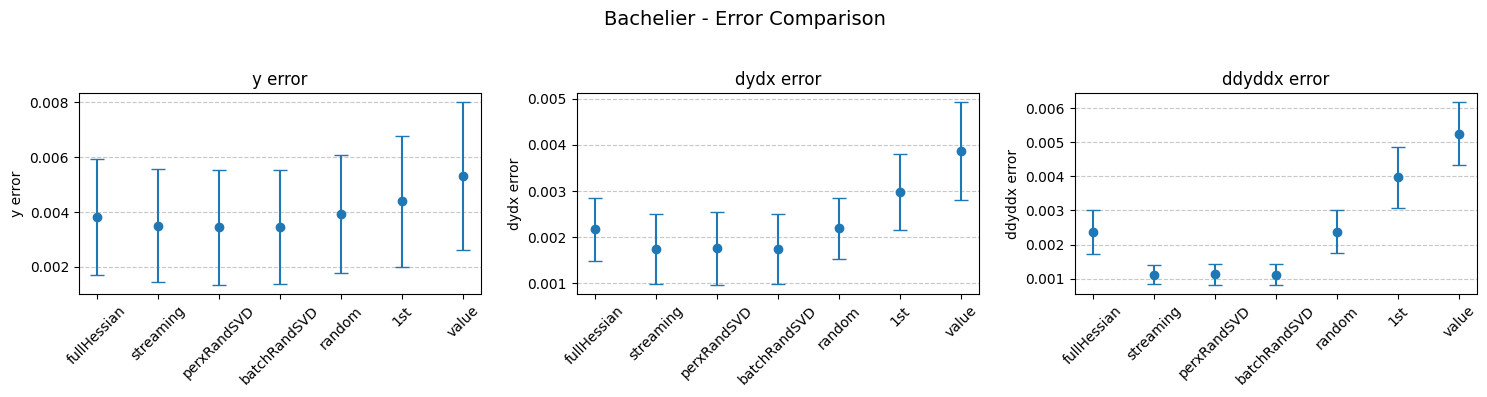

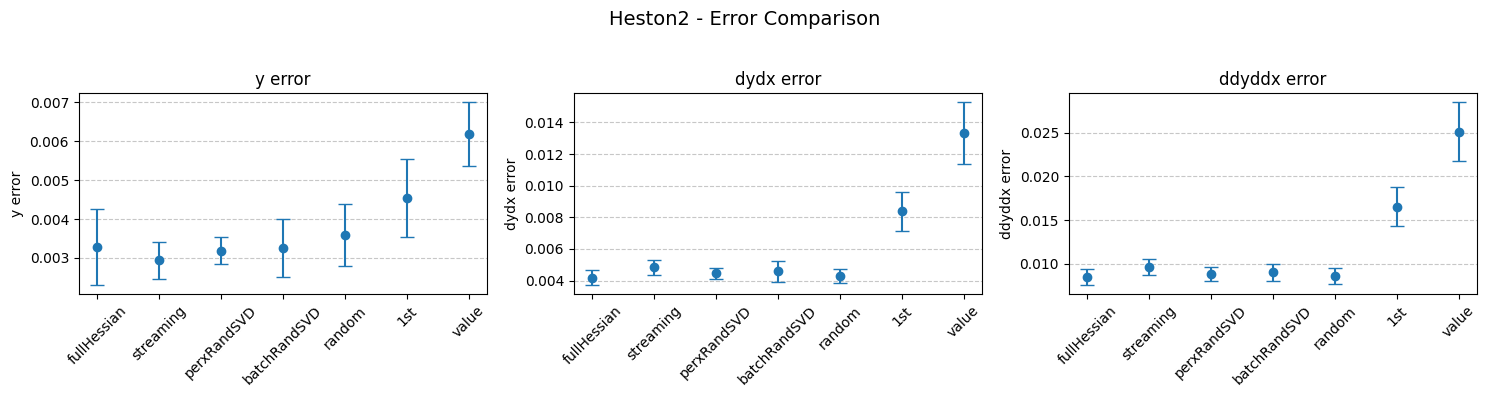

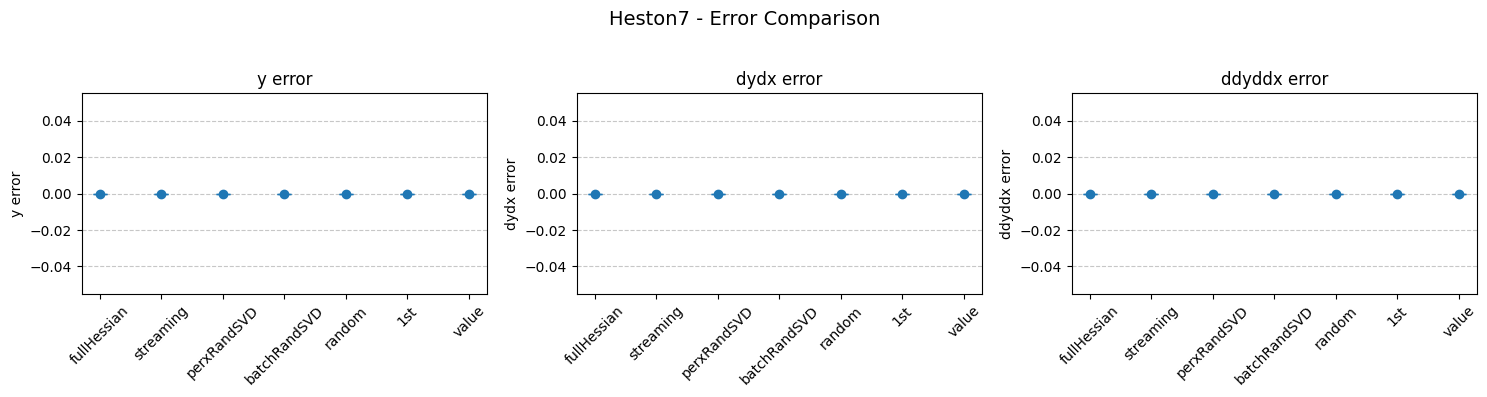

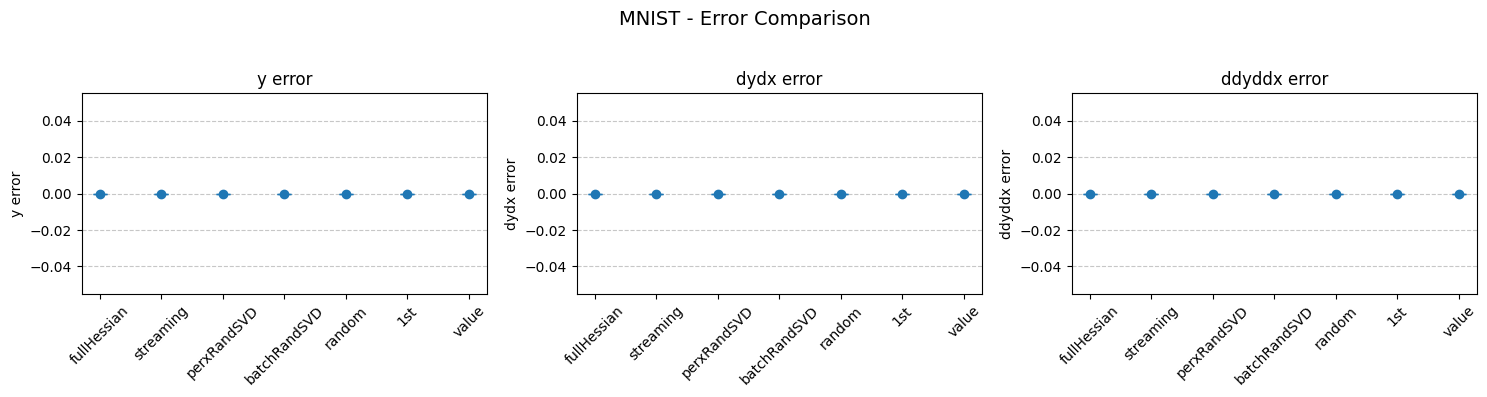

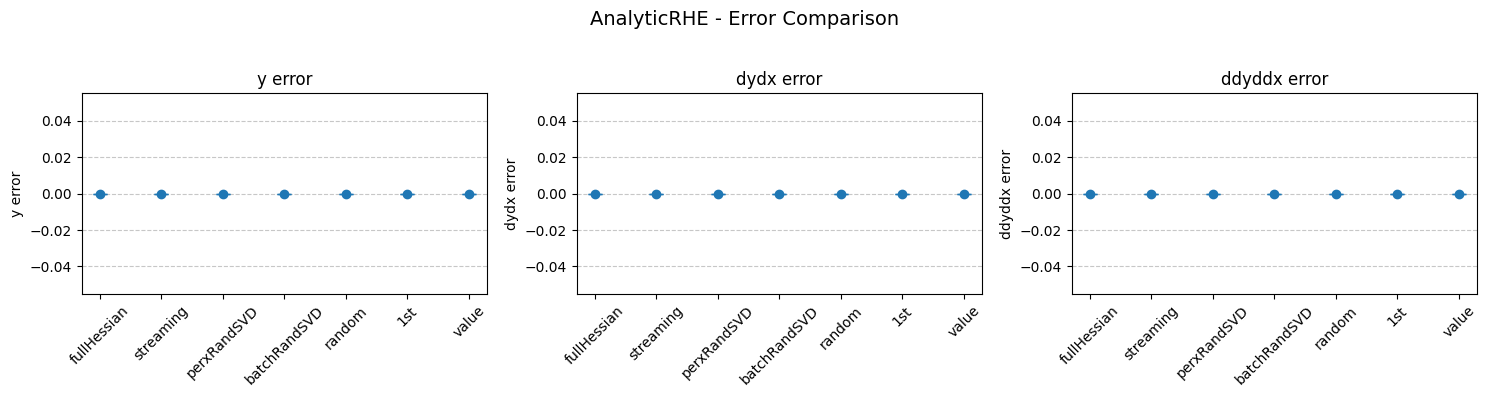

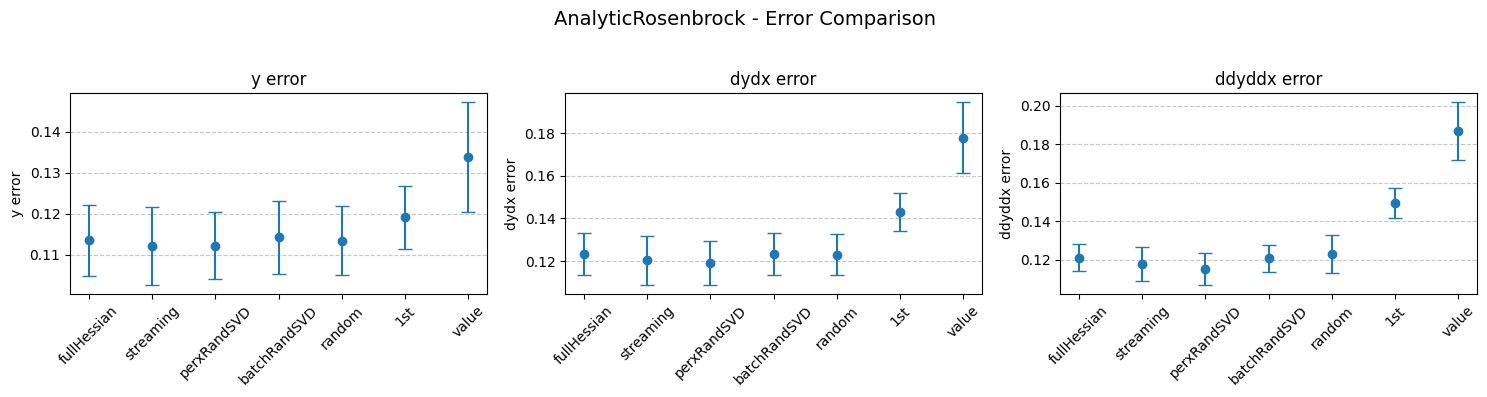

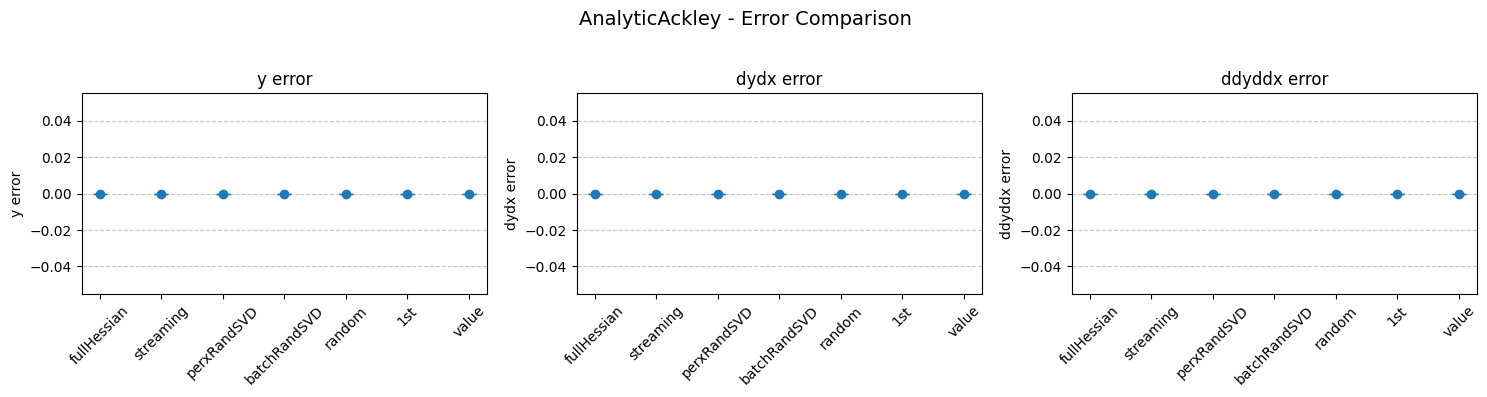

In [17]:
import matplotlib.pyplot as plt
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    error_types = [("y error", "y error"), ("dydx error", "dydx error"), ("ddyddx error", "ddyddx error")]

    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()


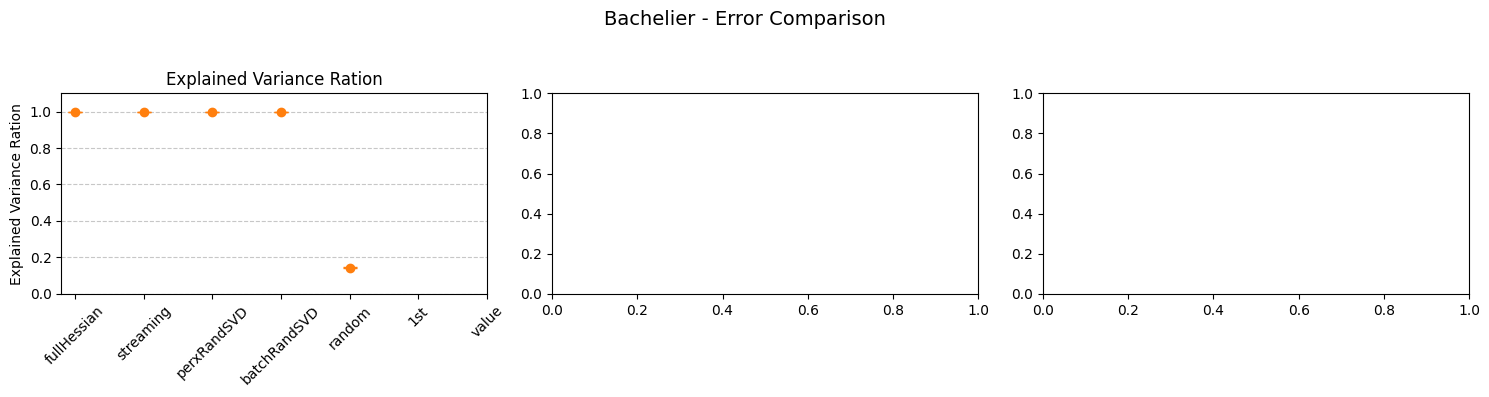

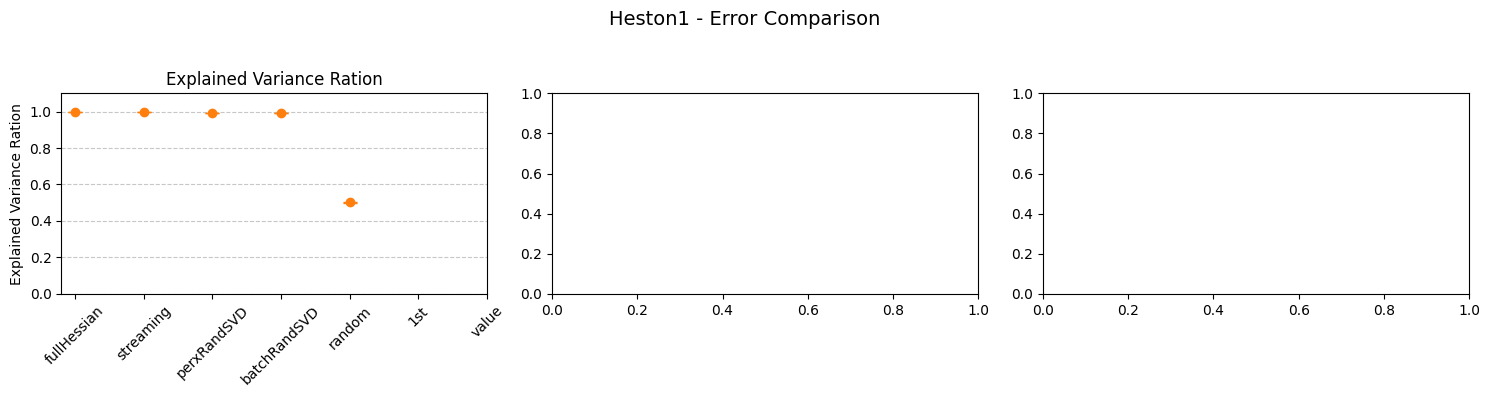

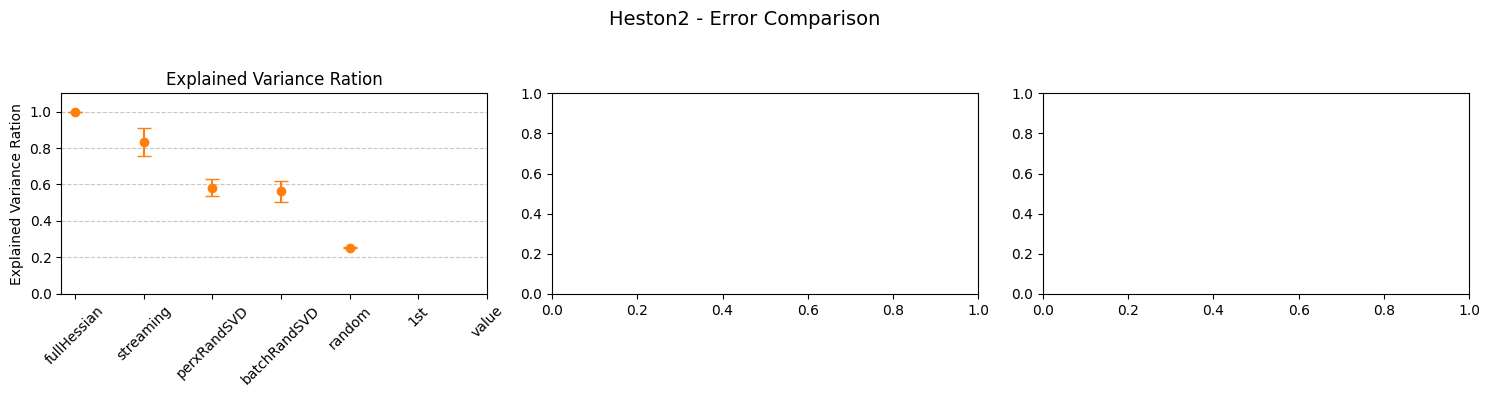

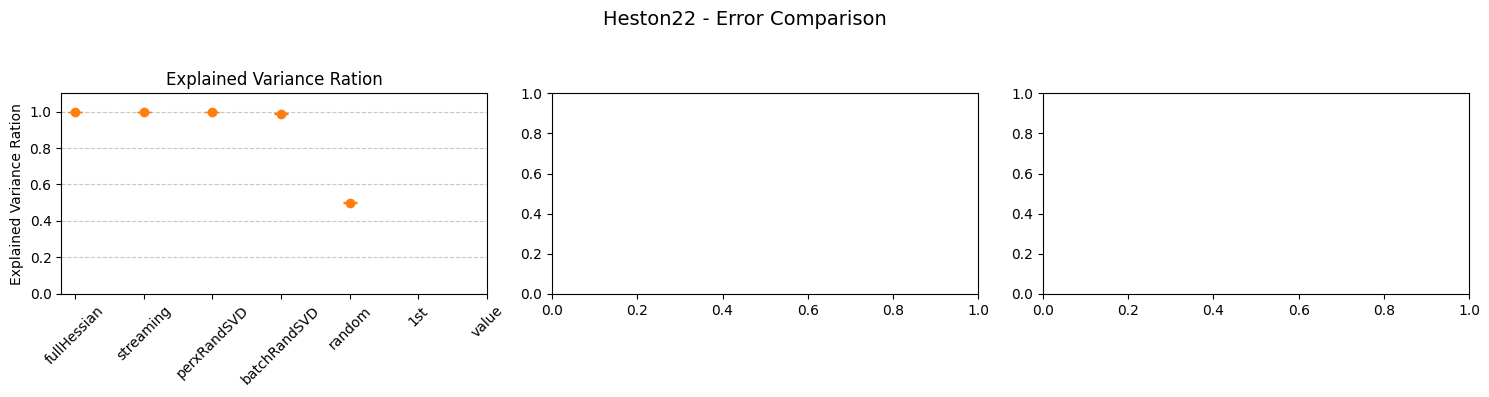

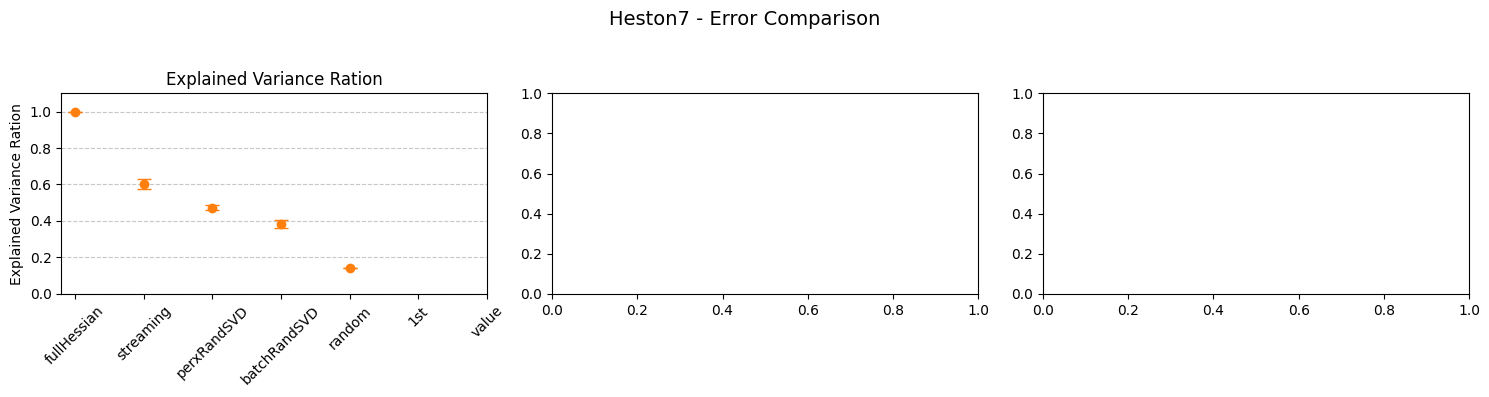

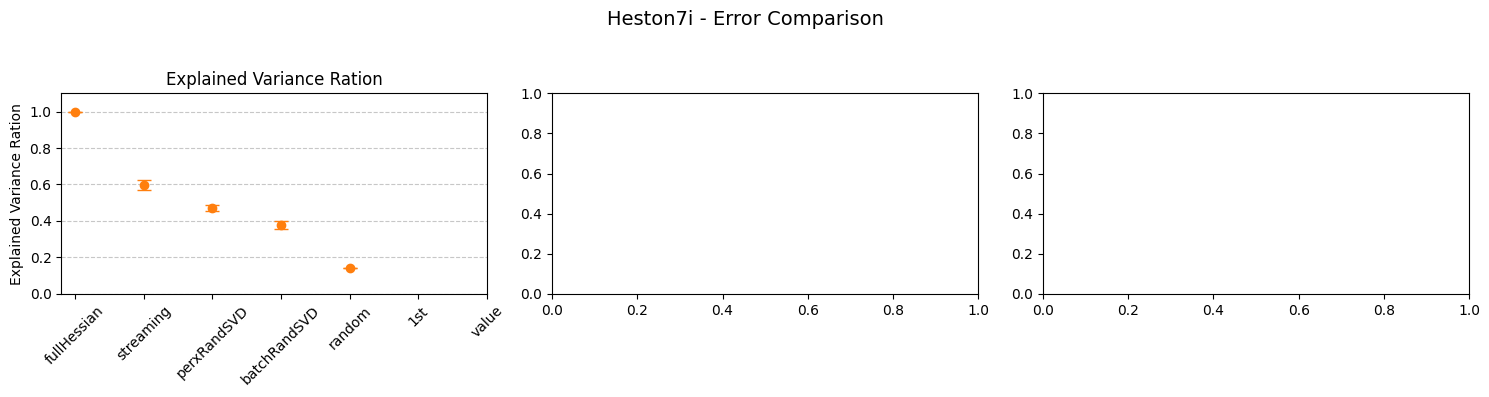

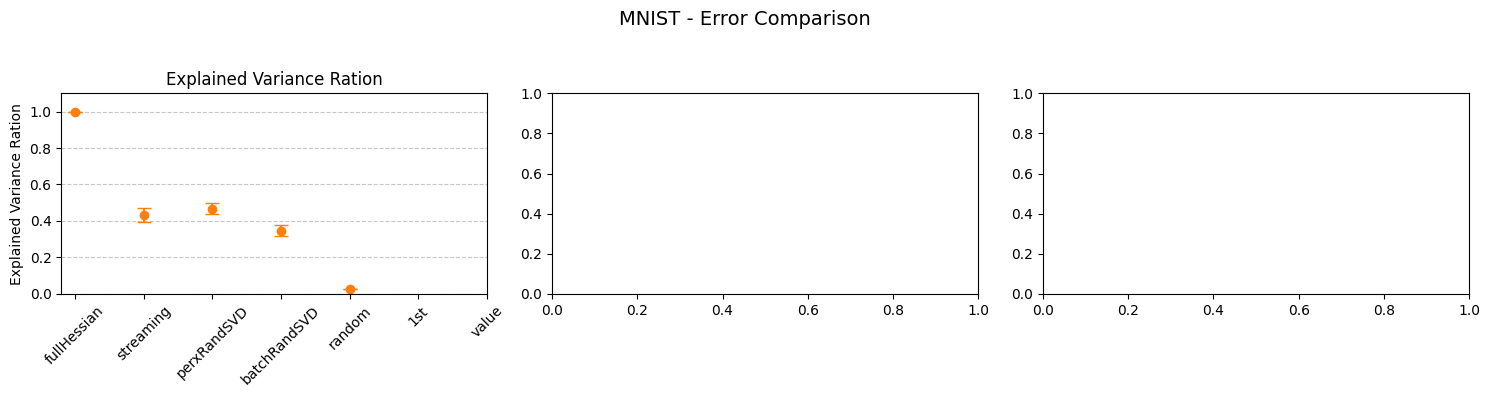

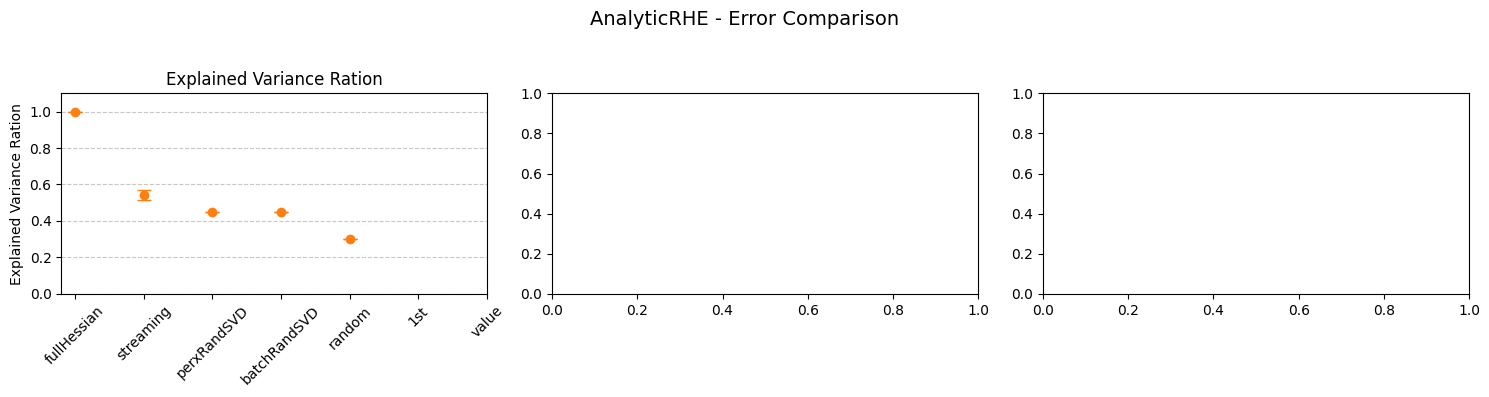

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    error_types = [("Explained Variance Ration", "evr")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    
    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='tab:orange')
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()
